In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv('../codes/data_syn.csv')

/var/folders/v6/43nstwv52771z0q7sjpfqzv00000gn/T/ipykernel_58522/1364955041.py:20: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/Users/kayadetunji/anaconda3/envs/kaymacmini/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


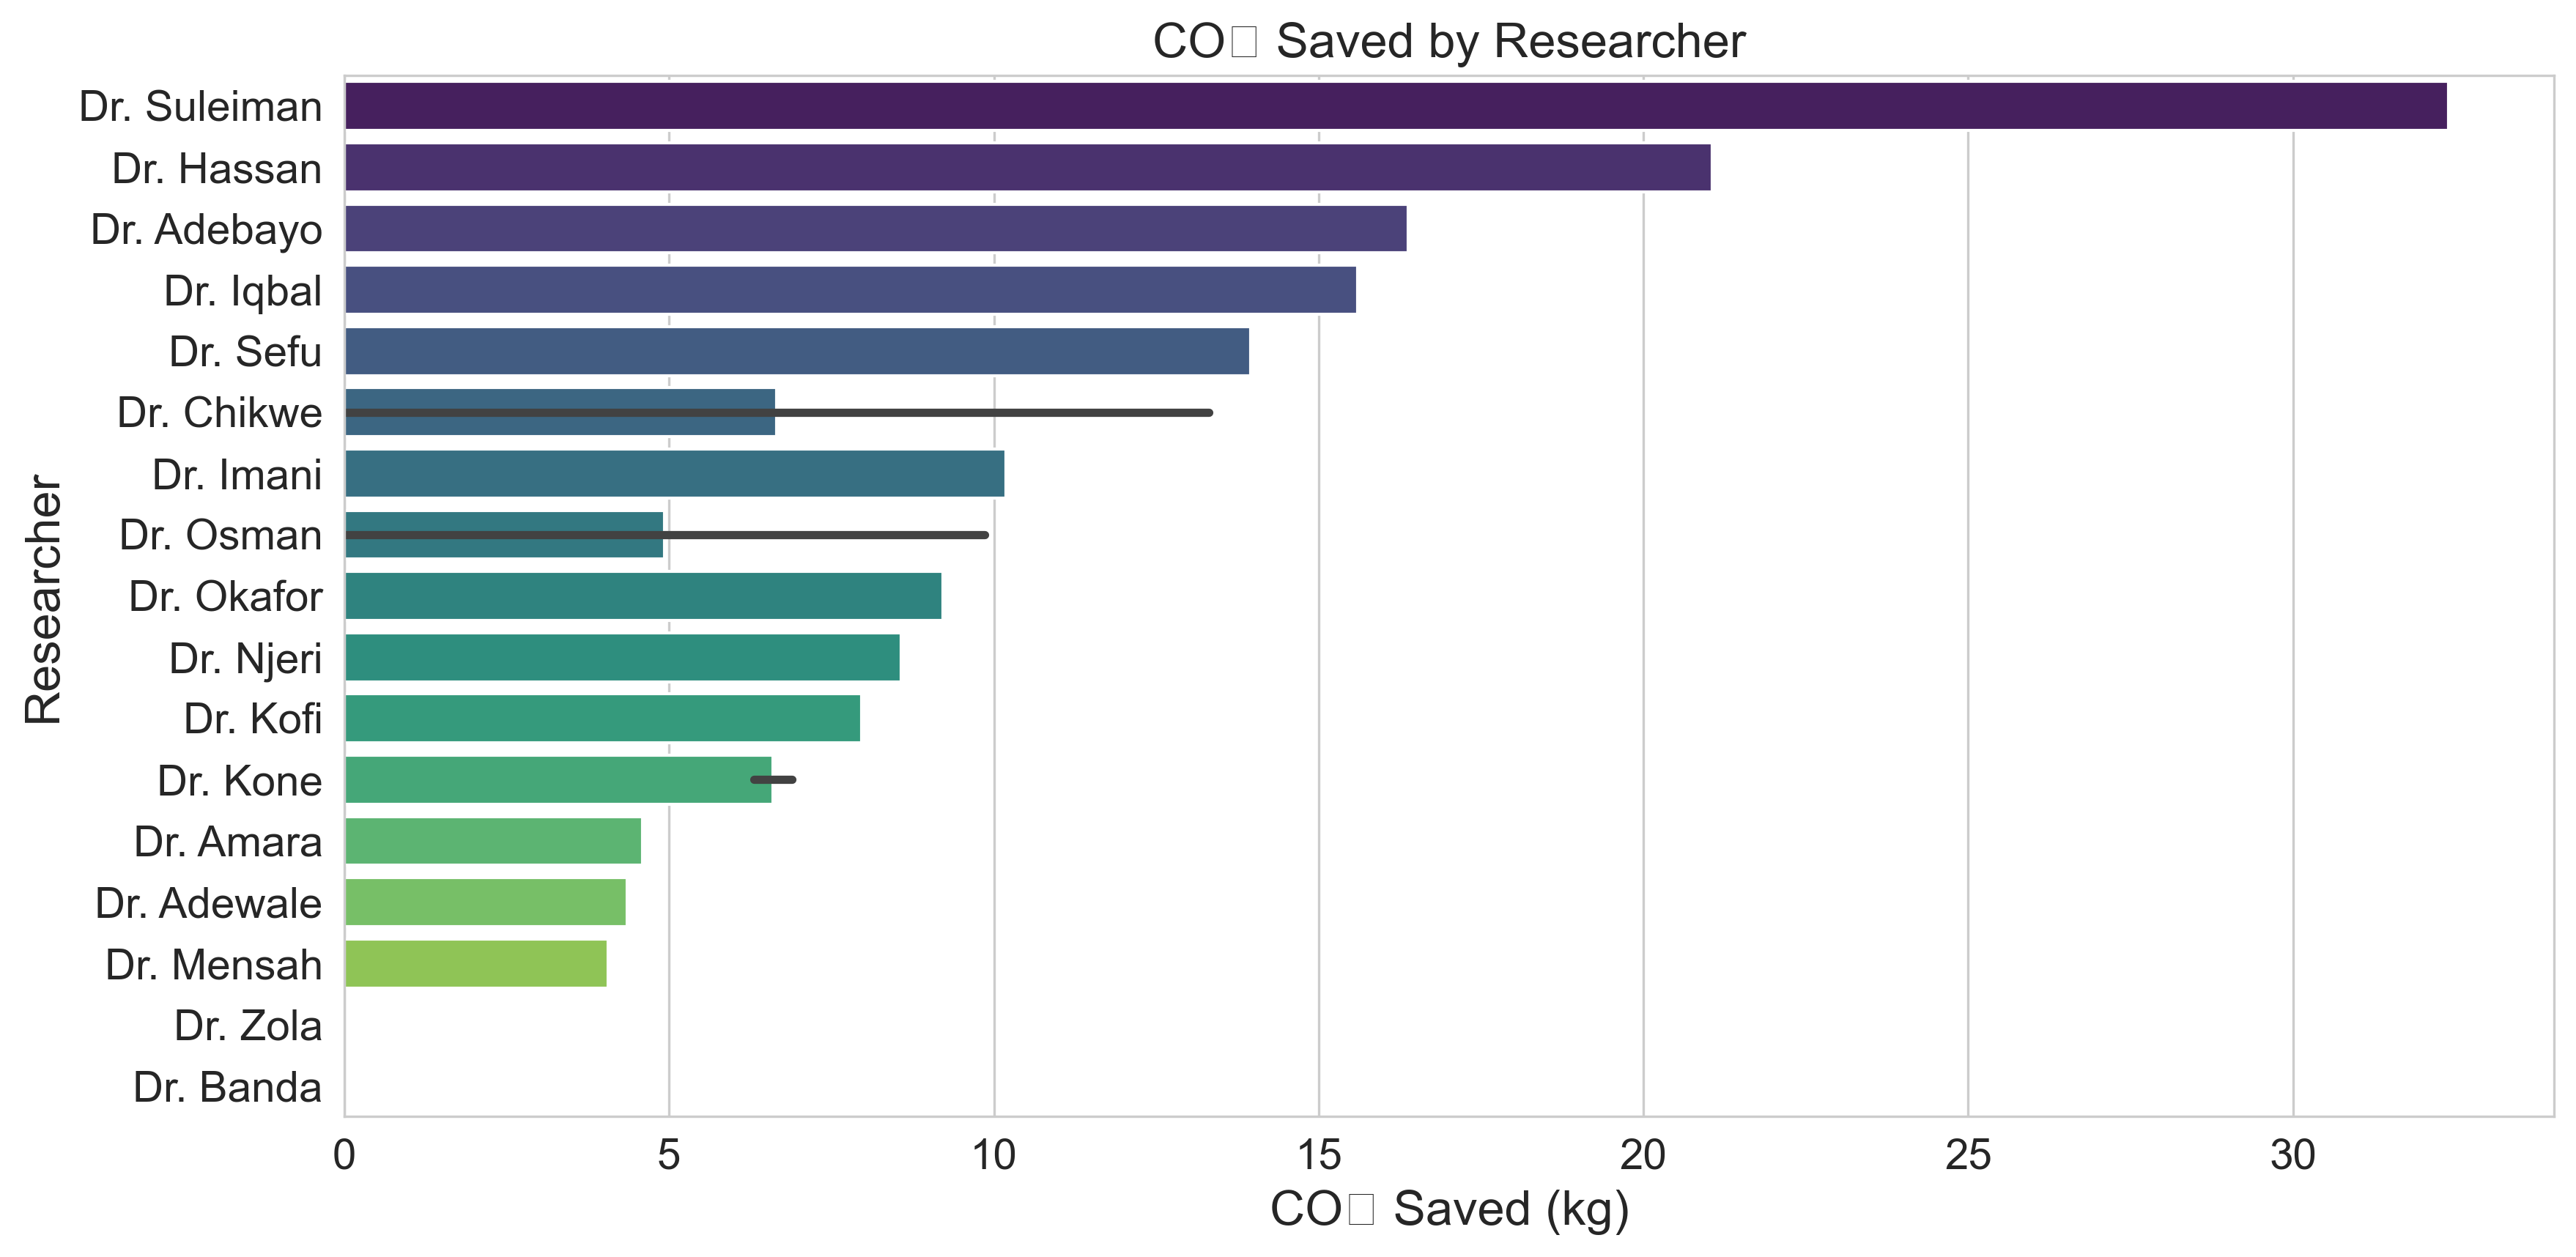

In [48]:
# Set style
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 16,            # Base font size
    'axes.titlesize': 16,       # Title font size
    'axes.labelsize': 14,       # Axis labels
    'legend.fontsize': 14,      # Legend font
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})
sns.set_style("whitegrid")

# 1. CO2 Saved by Researcher
plt.figure(figsize=(12, 6), dpi=300)
top_co2 = df.sort_values(by="CO2 Saved (kg)", ascending=False)
sns.barplot(x="CO2 Saved (kg)", y="Researcher", data=top_co2, palette="viridis")
plt.title("CO₂ Saved by Researcher")
plt.xlabel("CO₂ Saved (kg)")
plt.ylabel("Researcher")
plt.tight_layout()
plt.show()


/var/folders/v6/43nstwv52771z0q7sjpfqzv00000gn/T/ipykernel_58522/1864859626.py:8: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/var/folders/v6/43nstwv52771z0q7sjpfqzv00000gn/T/ipykernel_58522/1864859626.py:8: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  plt.tight_layout()
/Users/kayadetunji/anaconda3/envs/kaymacmini/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kayadetunji/anaconda3/envs/kaymacmini/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


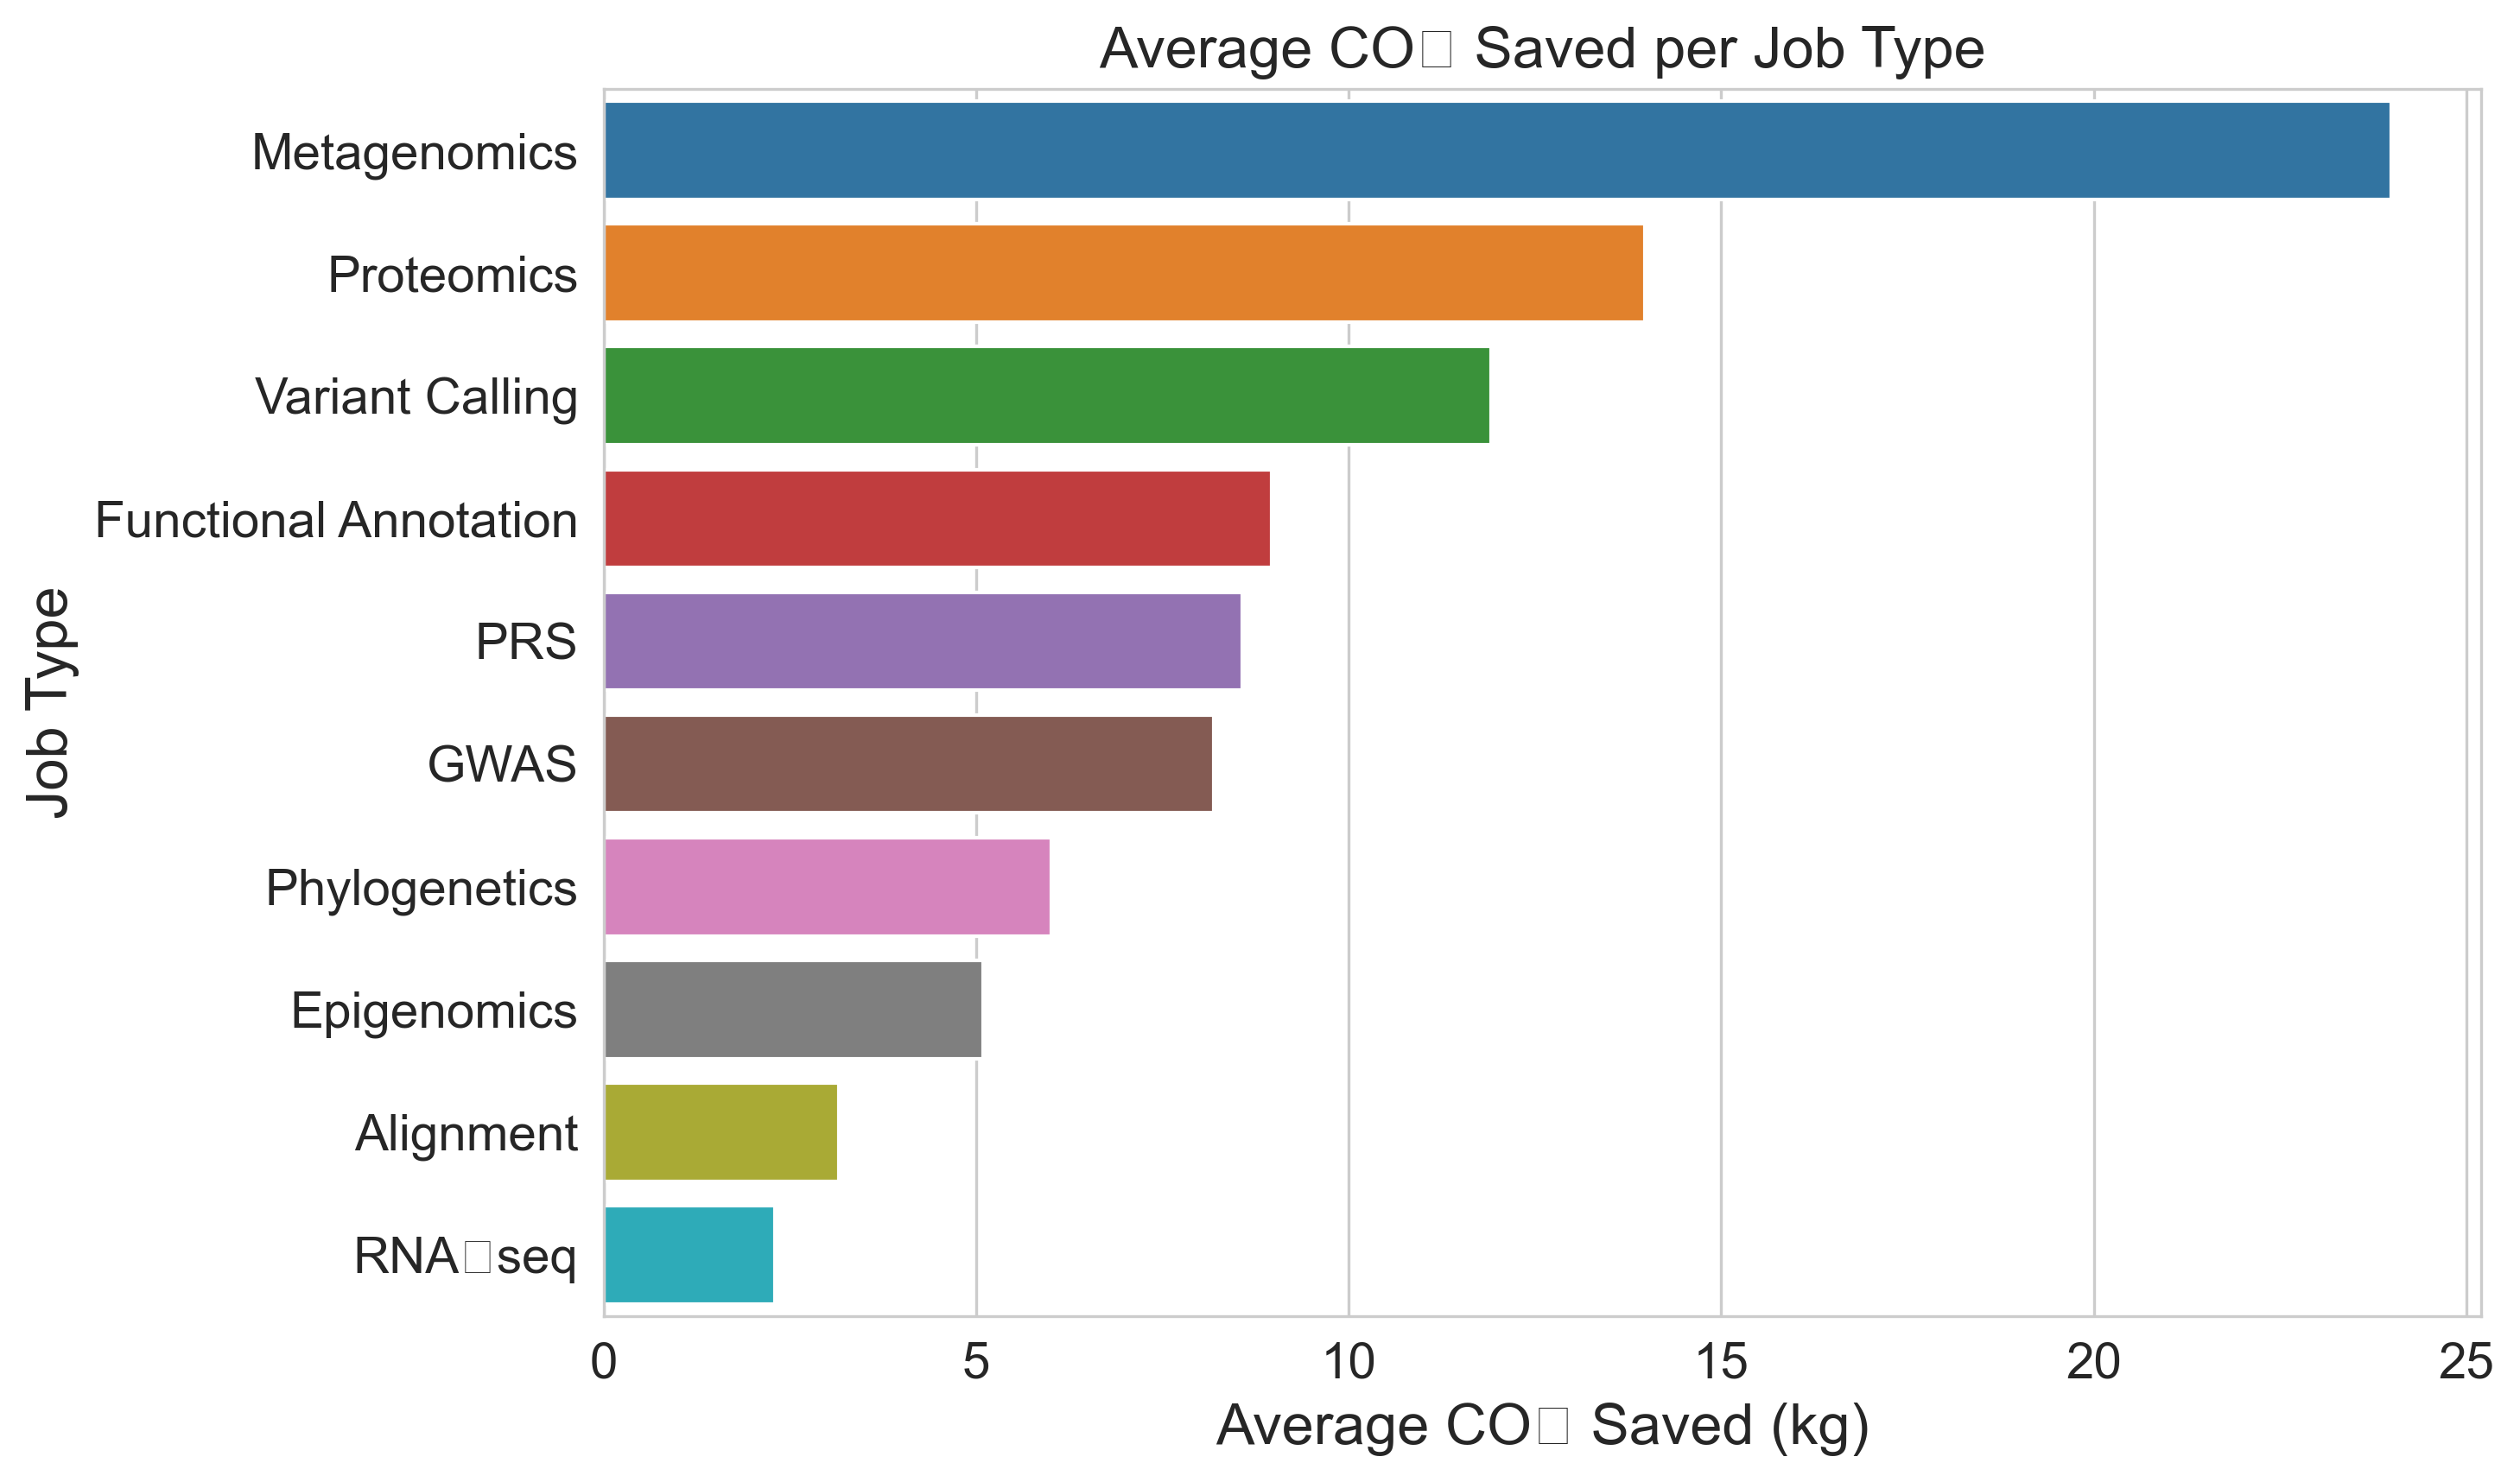

In [49]:

# 2. Avg CO2 Saved per Job Type
plt.figure(figsize=(10, 6), dpi=300)
job_co2 = df.groupby("Job Type")["CO2 Saved (kg)"].mean().sort_values(ascending=False)
sns.barplot(x=job_co2.values, y=job_co2.index)
plt.title("Average CO₂ Saved per Job Type")
plt.xlabel("Average CO₂ Saved (kg)")
plt.ylabel("Job Type")
plt.tight_layout()
plt.show()


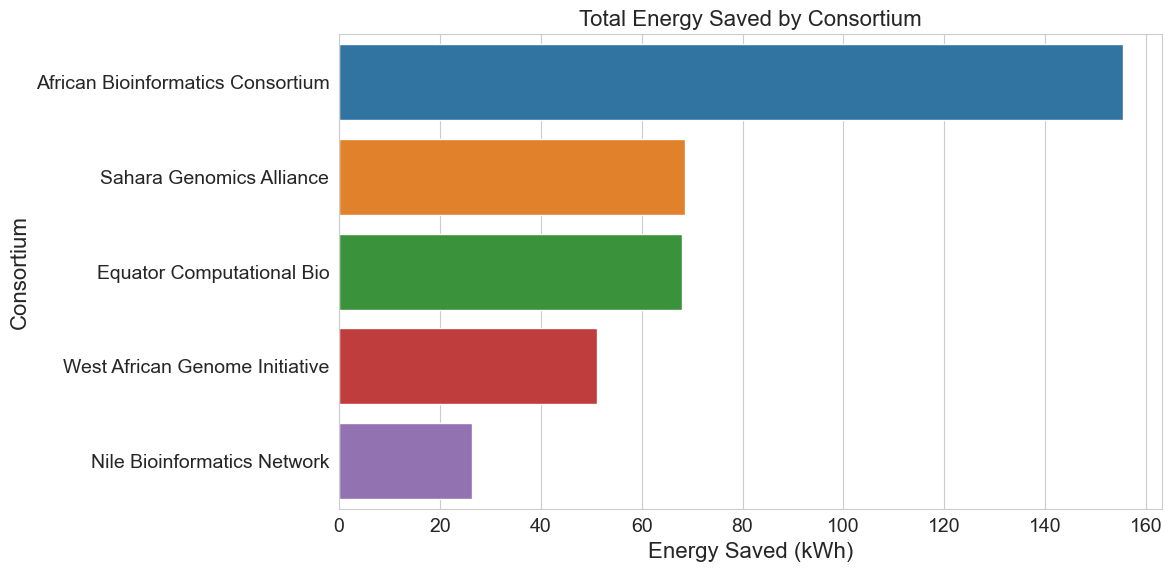

In [50]:

# 3. Energy Saved (Baseline - Optimized) by Consortium
df["Energy Saved (kWh)"] = df["Baseline Energy (kWh)"] - df["Optimized Energy (kWh)"]
plt.figure(figsize=(12, 6))
consortium_savings = df.groupby("Consortium")["Energy Saved (kWh)"].sum().sort_values(ascending=False)
sns.barplot(x=consortium_savings.values, y=consortium_savings.index)
plt.title("Total Energy Saved by Consortium")
plt.xlabel("Energy Saved (kWh)")
plt.ylabel("Consortium")
plt.tight_layout()
plt.show()


/var/folders/v6/43nstwv52771z0q7sjpfqzv00000gn/T/ipykernel_58522/2242971931.py:8: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  plt.tight_layout()
/var/folders/v6/43nstwv52771z0q7sjpfqzv00000gn/T/ipykernel_58522/2242971931.py:8: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  plt.tight_layout()
/Users/kayadetunji/anaconda3/envs/kaymacmini/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kayadetunji/anaconda3/envs/kaymacmini/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


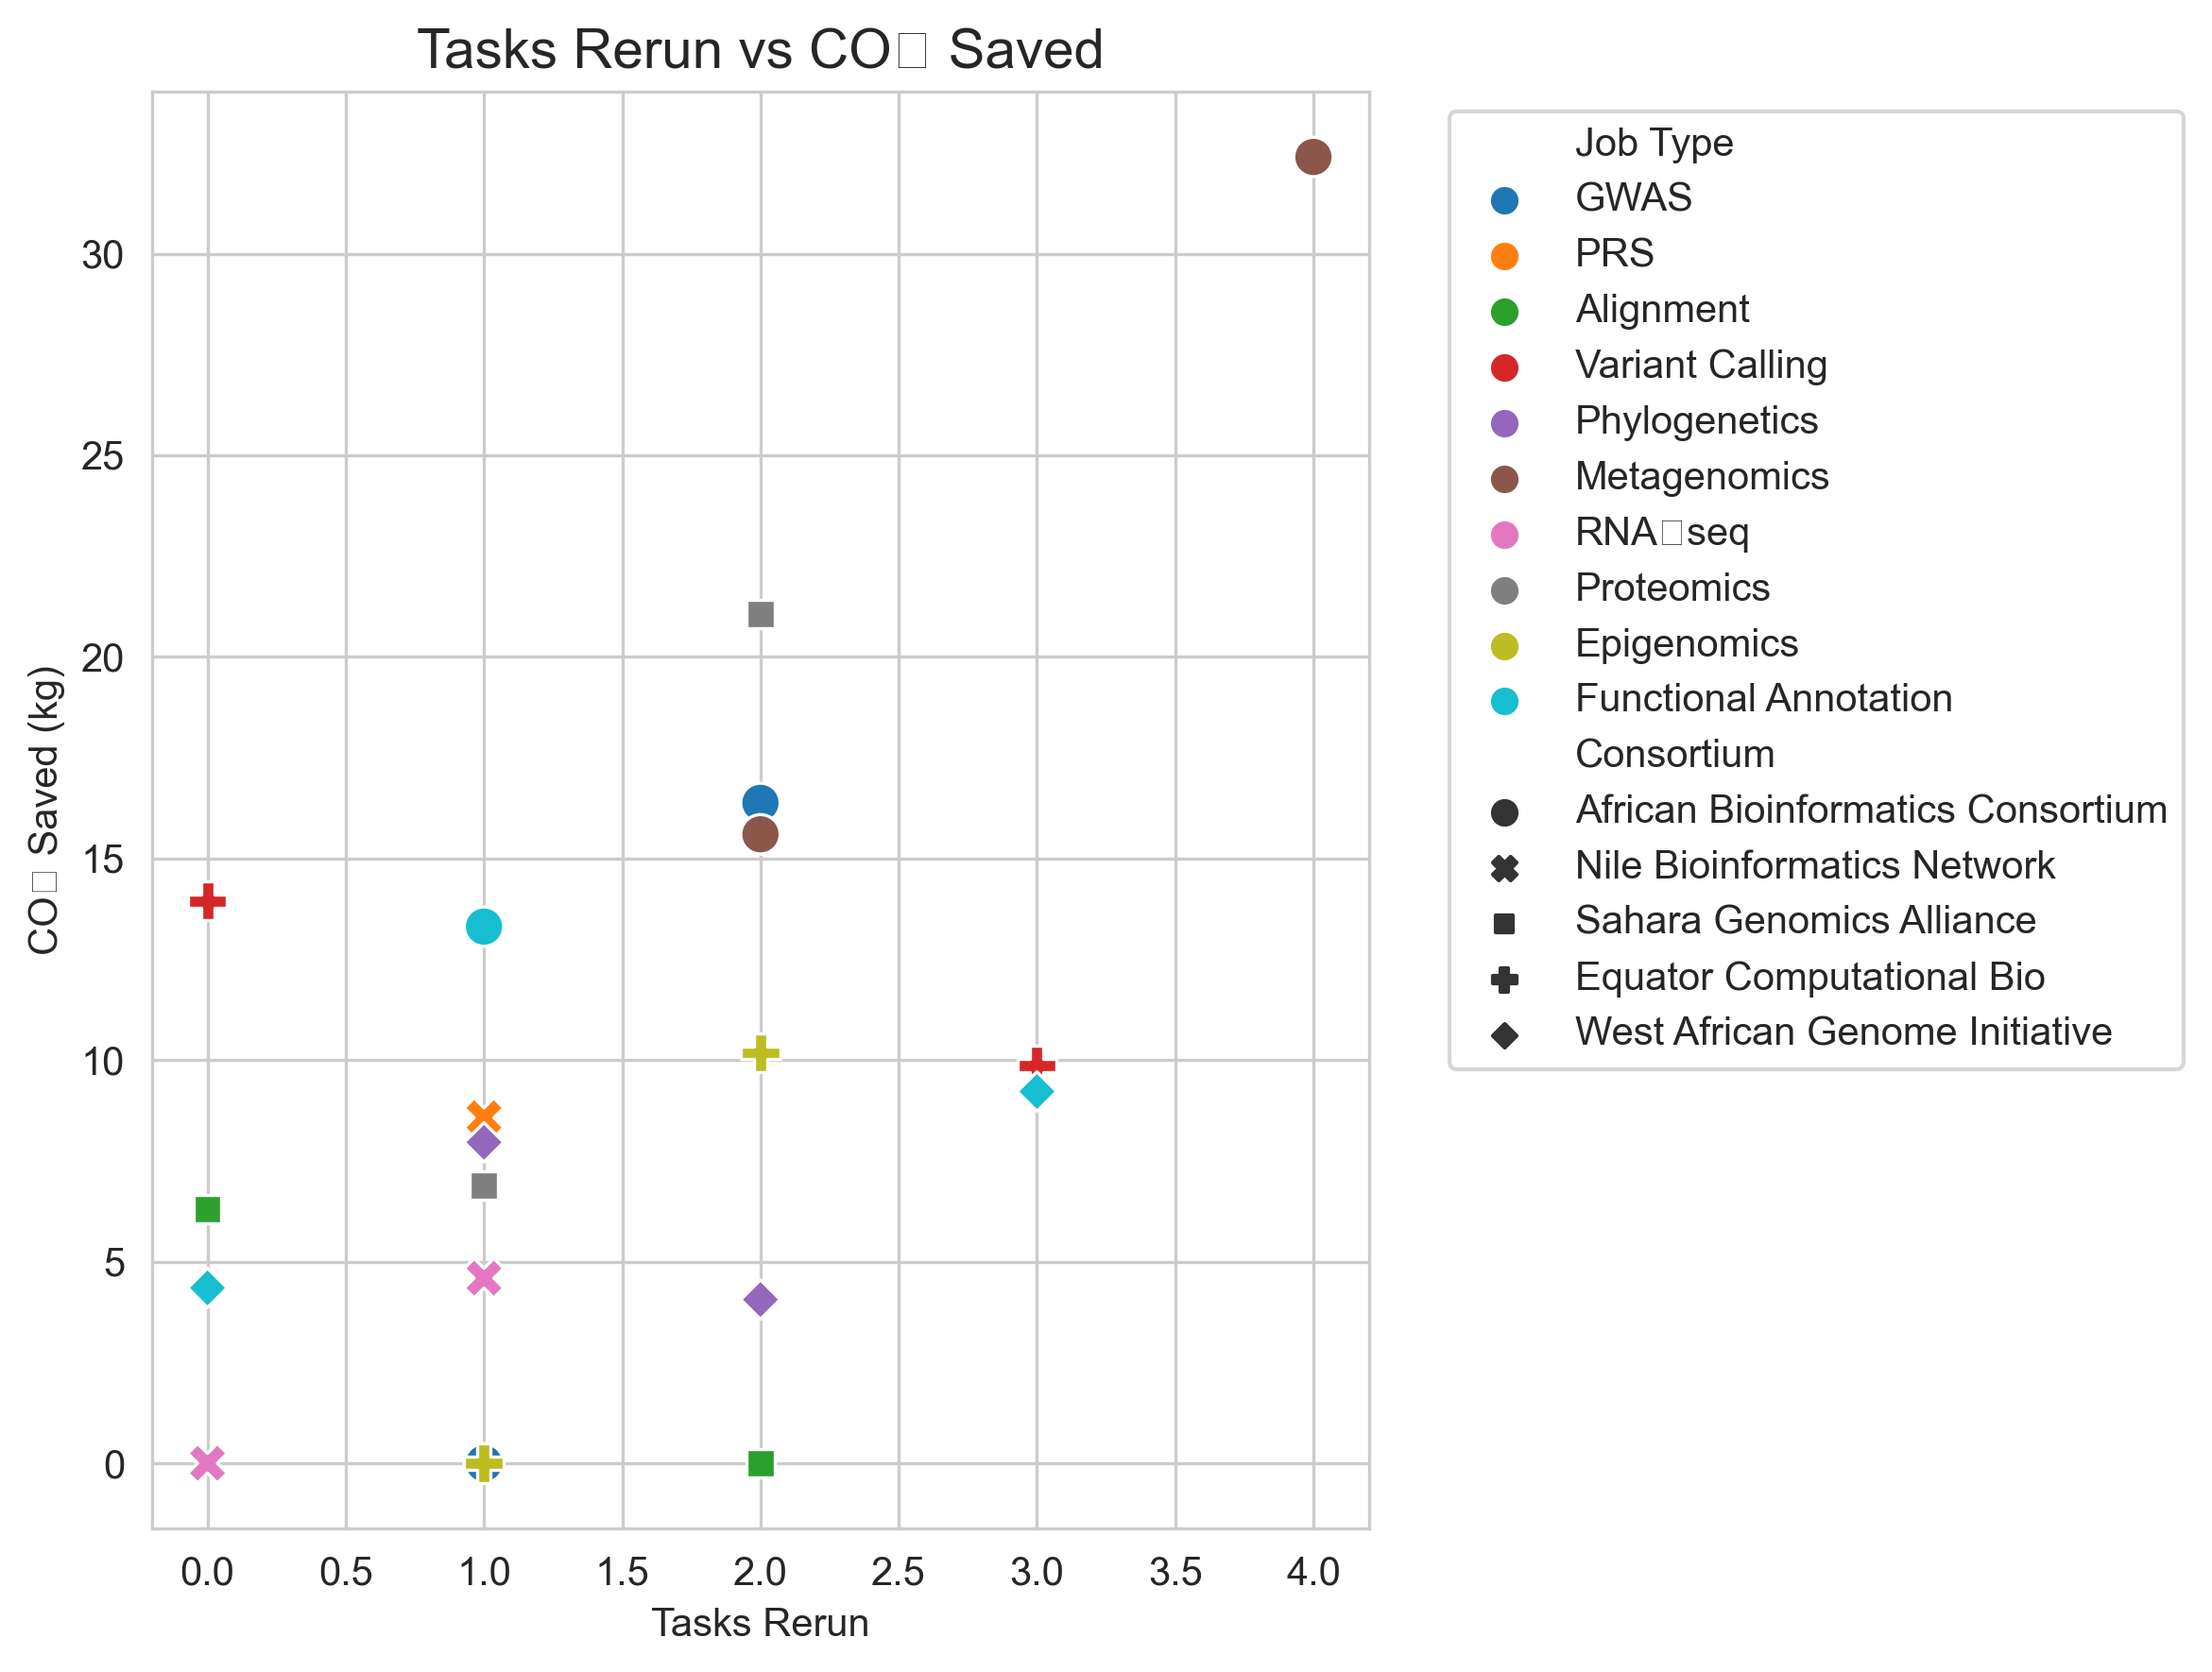

In [42]:

# 4. Correlation between Tasks Rerun and CO2 Saved
plt.figure(figsize=(8, 6), dpi=300)
sns.scatterplot(data=df, x="Tasks Rerun", y="CO2 Saved (kg)", hue="Job Type", style="Consortium", s=100)
plt.title("Tasks Rerun vs CO₂ Saved")
plt.xlabel("Tasks Rerun")
plt.ylabel("CO₂ Saved (kg)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


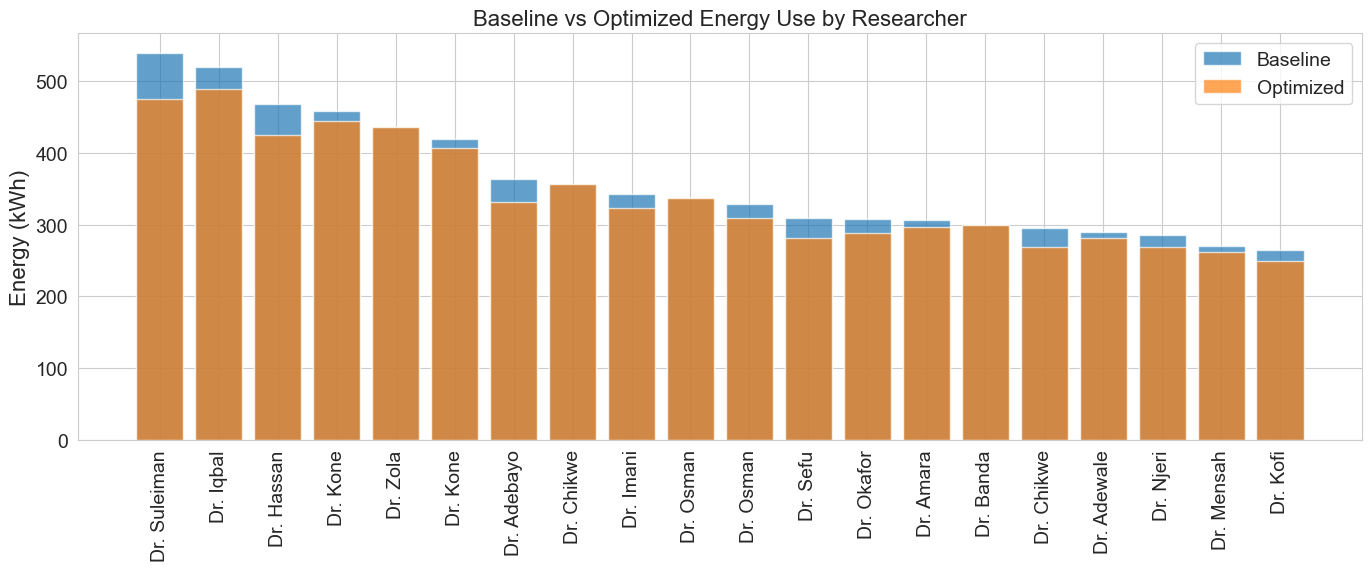

In [51]:

# 5. Baseline vs Optimized Energy Use by Researcher
plt.figure(figsize=(14, 6))
sorted_df = df.sort_values(by="Baseline Energy (kWh)", ascending=False)
x = range(len(sorted_df))
plt.bar(x, sorted_df["Baseline Energy (kWh)"], label='Baseline', alpha=0.7)
plt.bar(x, sorted_df["Optimized Energy (kWh)"], label='Optimized', alpha=0.7)
plt.xticks(x, sorted_df["Researcher"], rotation=90)
plt.ylabel("Energy (kWh)")
plt.title("Baseline vs Optimized Energy Use by Researcher")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
import statsmodels.api as sm

# Prepare features and target for regression
features = df[["Tasks Rerun", "Subtasks Delegated", "Runtime Increase (%)"]]
target = df["CO2 Saved (kg)"]

# Add constant for intercept
features = sm.add_constant(features)

# Fit linear regression model
model = sm.OLS(target, features).fit()
model_summary = model.summary()

model_summary.tables[1]  # Coefficients and significance table

,coef,std err,t,P>|t|,[0.025,0.975]
const,-2.2148,1.242,-1.783,0.093,-4.836,0.407
Tasks Rerun,1.3358,0.678,1.971,0.065,-0.094,2.766
Subtasks Delegated,0.2217,0.024,9.147,0.000,0.171,0.273
Runtime Increase (%),1.1086,0.121,9.147,0.000,0.853,1.364


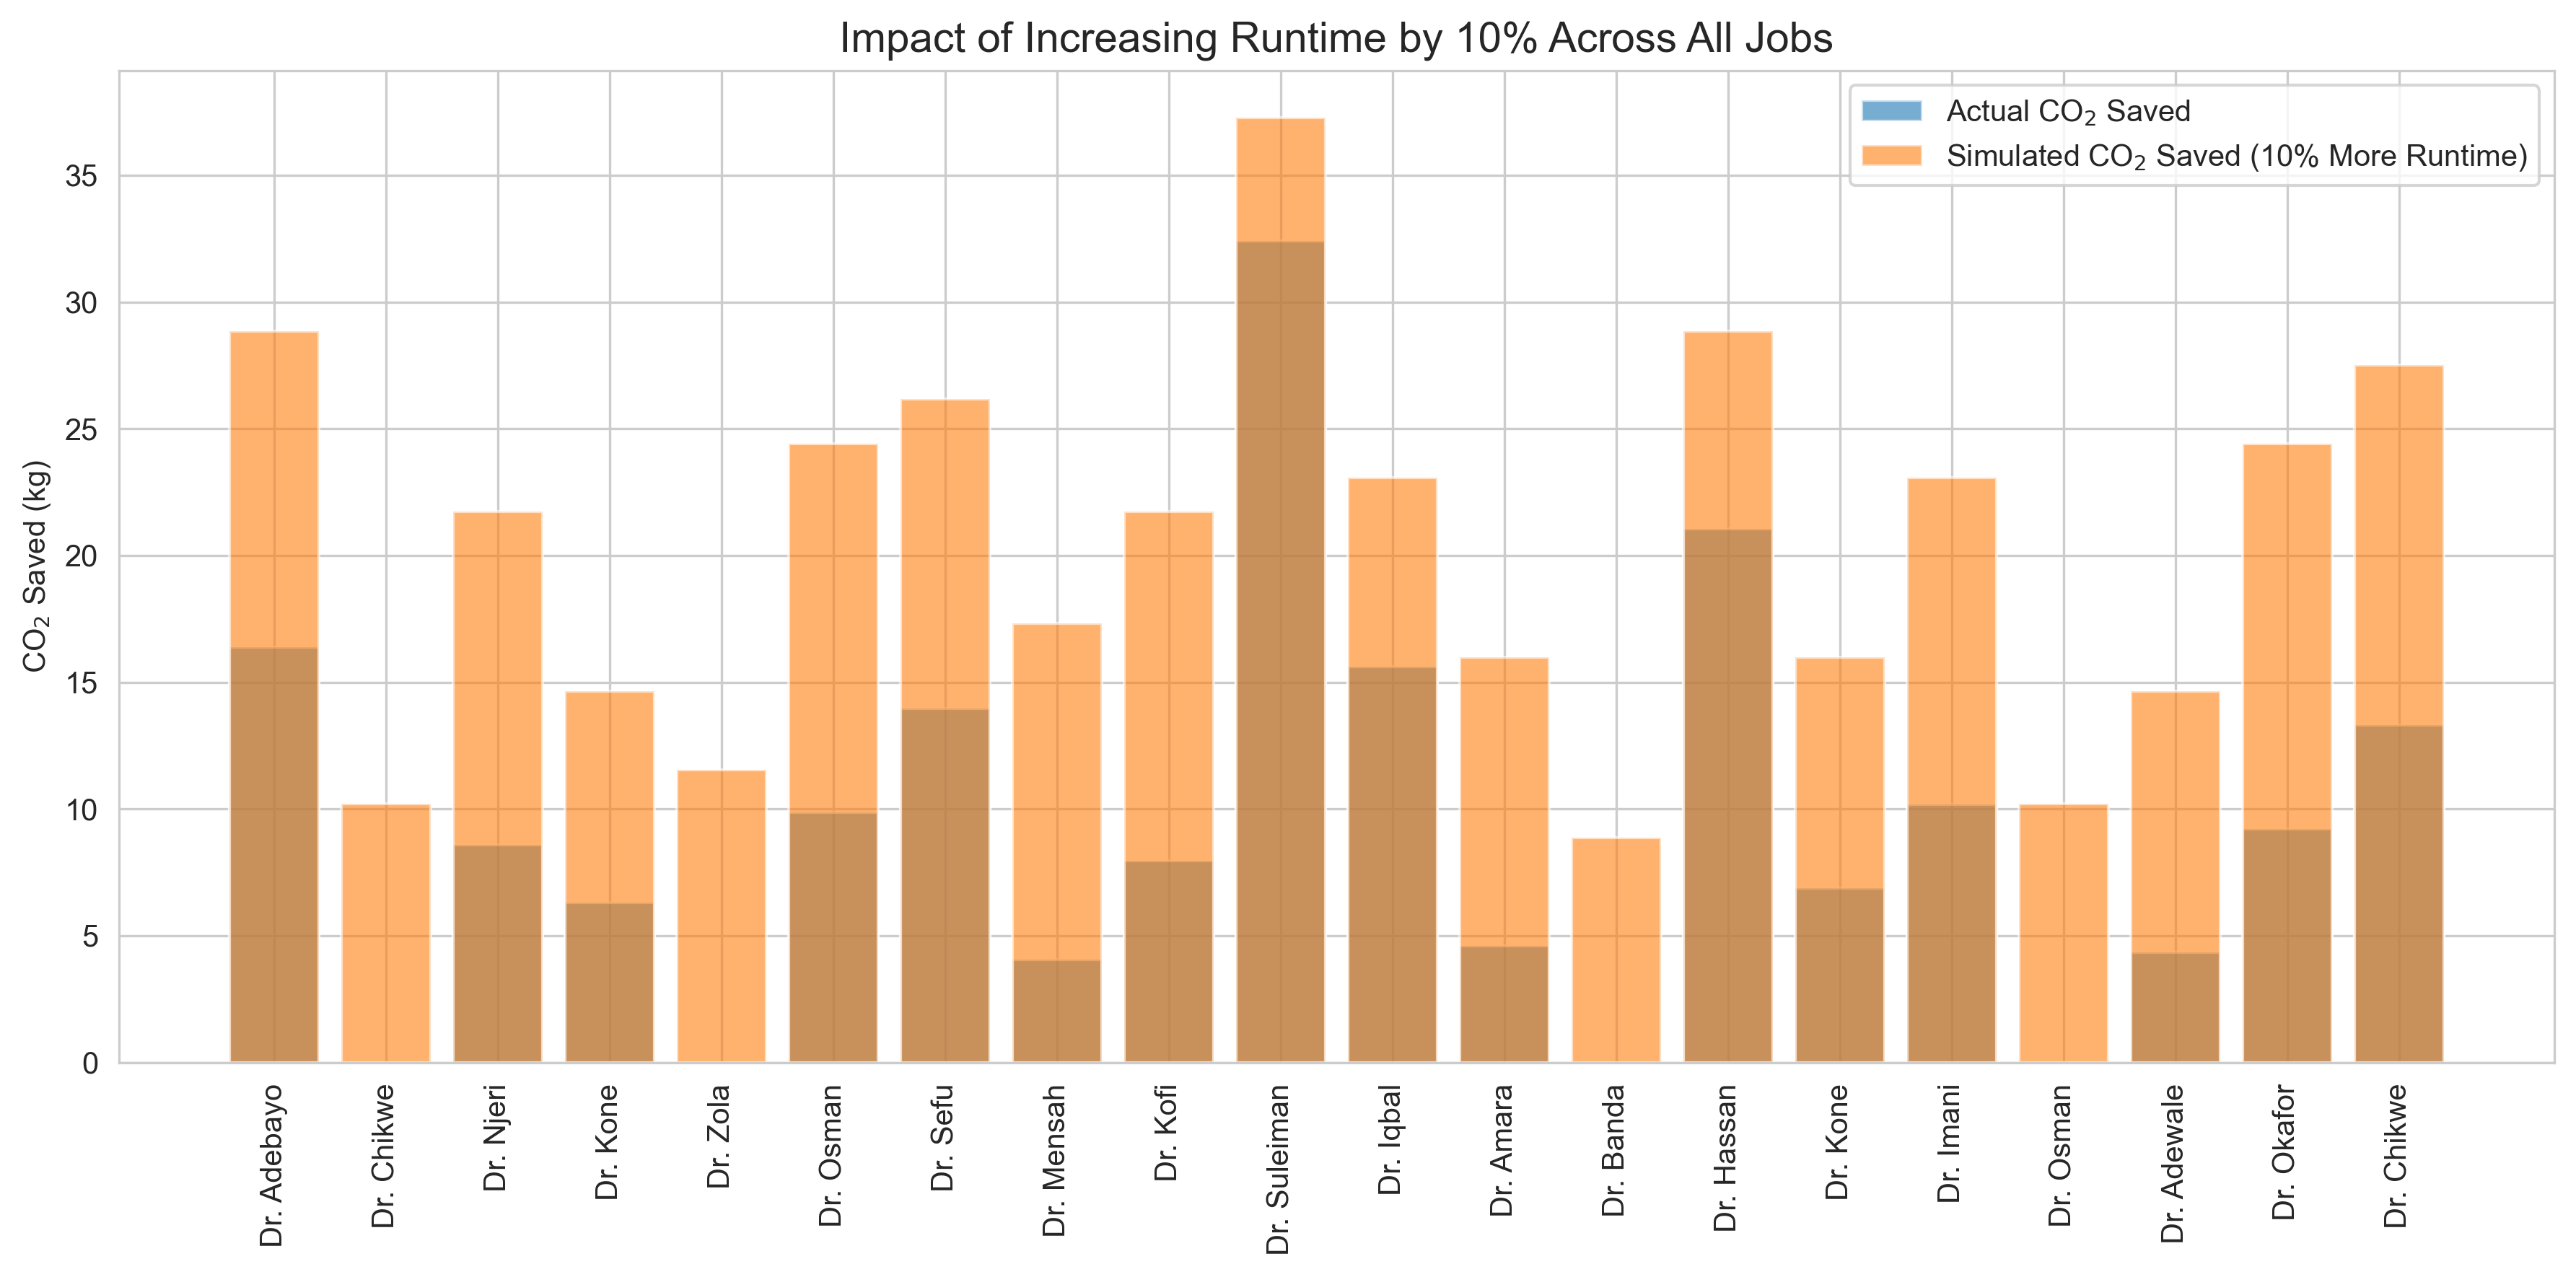

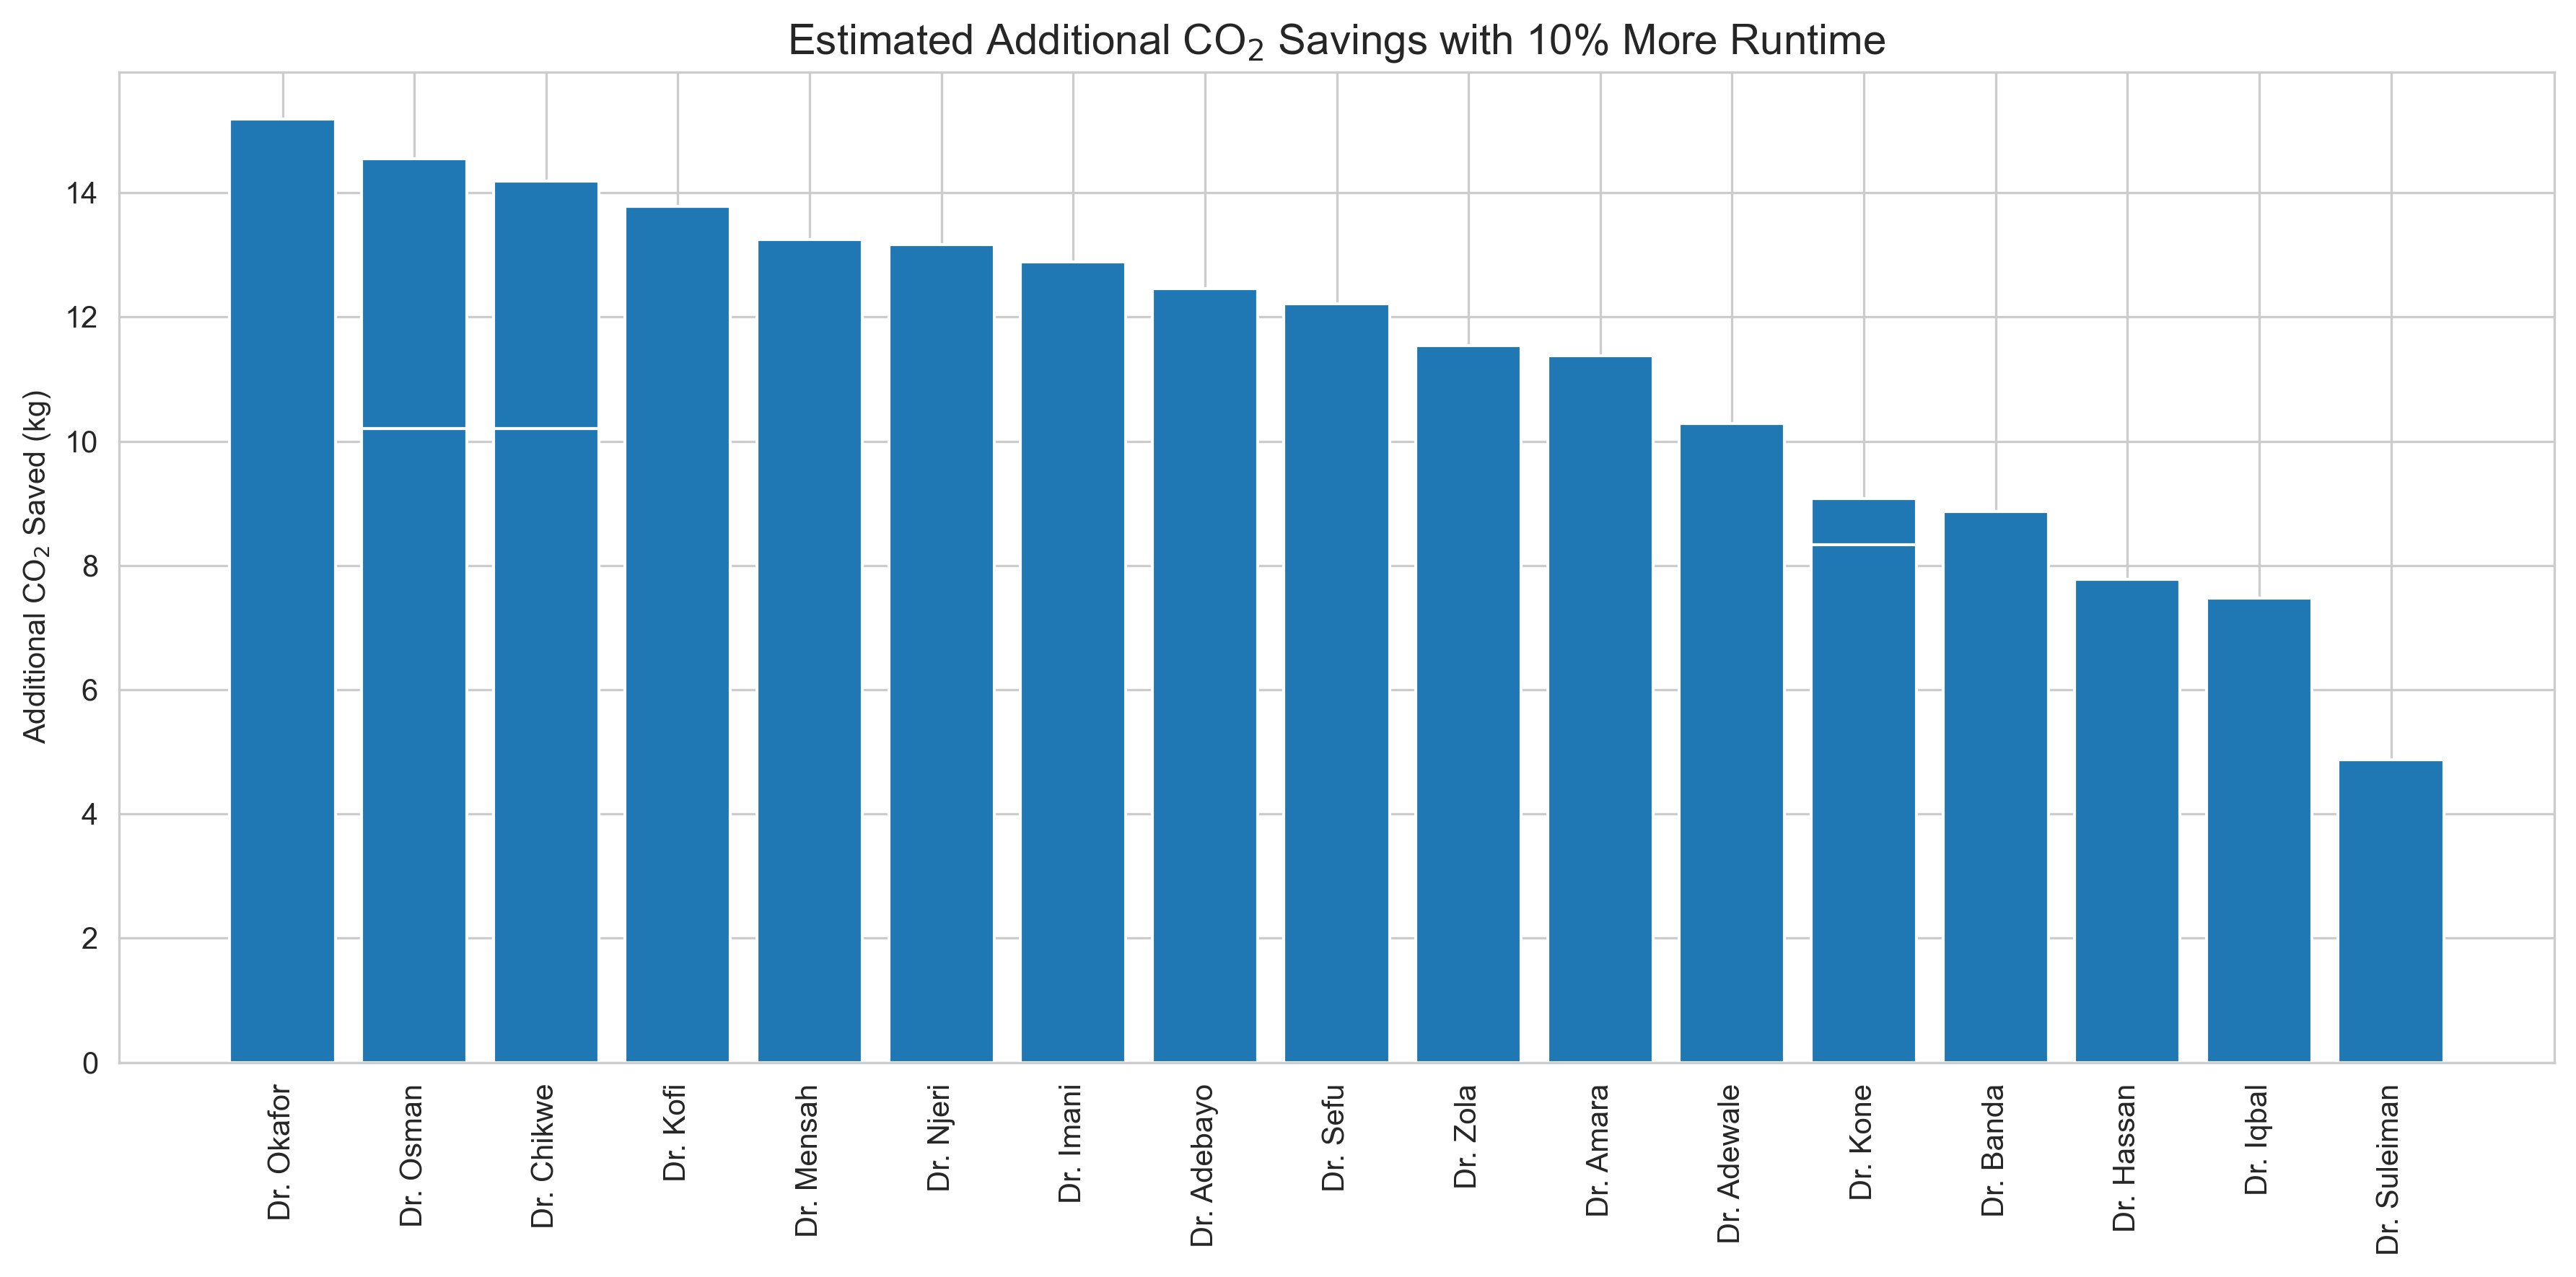

221.72026169706612

In [45]:
# Simulate a 10% increase in runtime across all jobs
# We'll use the model coefficients to estimate potential CO2 savings

# Clone original dataframe
df_simulated = df.copy()

# Increase runtime by 10%
df_simulated["Runtime Increase (%)"] += 10

# Predict new CO2 saved using the regression model
simulated_features = df_simulated[["Tasks Rerun", "Subtasks Delegated", "Runtime Increase (%)"]]
simulated_features = sm.add_constant(simulated_features)
df_simulated["Simulated CO2 Saved (kg)"] = model.predict(simulated_features)

# Compare actual vs simulated CO2 saved
df_simulated["Additional CO2 Saved (kg)"] = df_simulated["Simulated CO2 Saved (kg)"] - df["CO2 Saved (kg)"]

# Total additional CO2 saved across all jobs
total_additional_saved = df_simulated["Additional CO2 Saved (kg)"].sum()

# Visualize actual vs simulated CO2 saved
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6), dpi=300)
x = range(len(df_simulated))
plt.bar(x, df["CO2 Saved (kg)"], label='Actual CO$_2$ Saved', alpha=0.6)
plt.bar(x, df_simulated["Simulated CO2 Saved (kg)"], label='Simulated CO$_2$ Saved (10% More Runtime)', alpha=0.6)
plt.xticks(x, df["Researcher"], rotation=90)
plt.ylabel("CO$_2$ Saved (kg)")
plt.title("Impact of Increasing Runtime by 10% Across All Jobs")
plt.legend()
plt.tight_layout()
plt.show()

# Bar plot for additional CO2 savings from simulation
plt.figure(figsize=(12, 6), dpi=300)
df_simulated_sorted = df_simulated.sort_values(by="Additional CO2 Saved (kg)", ascending=False)
plt.bar(df_simulated_sorted["Researcher"], df_simulated_sorted["Additional CO2 Saved (kg)"])
plt.xticks(rotation=90)
plt.ylabel("Additional CO$_2$ Saved (kg)")
plt.title("Estimated Additional CO$_2$ Savings with 10% More Runtime")
plt.tight_layout()
plt.show()

total_additional_saved

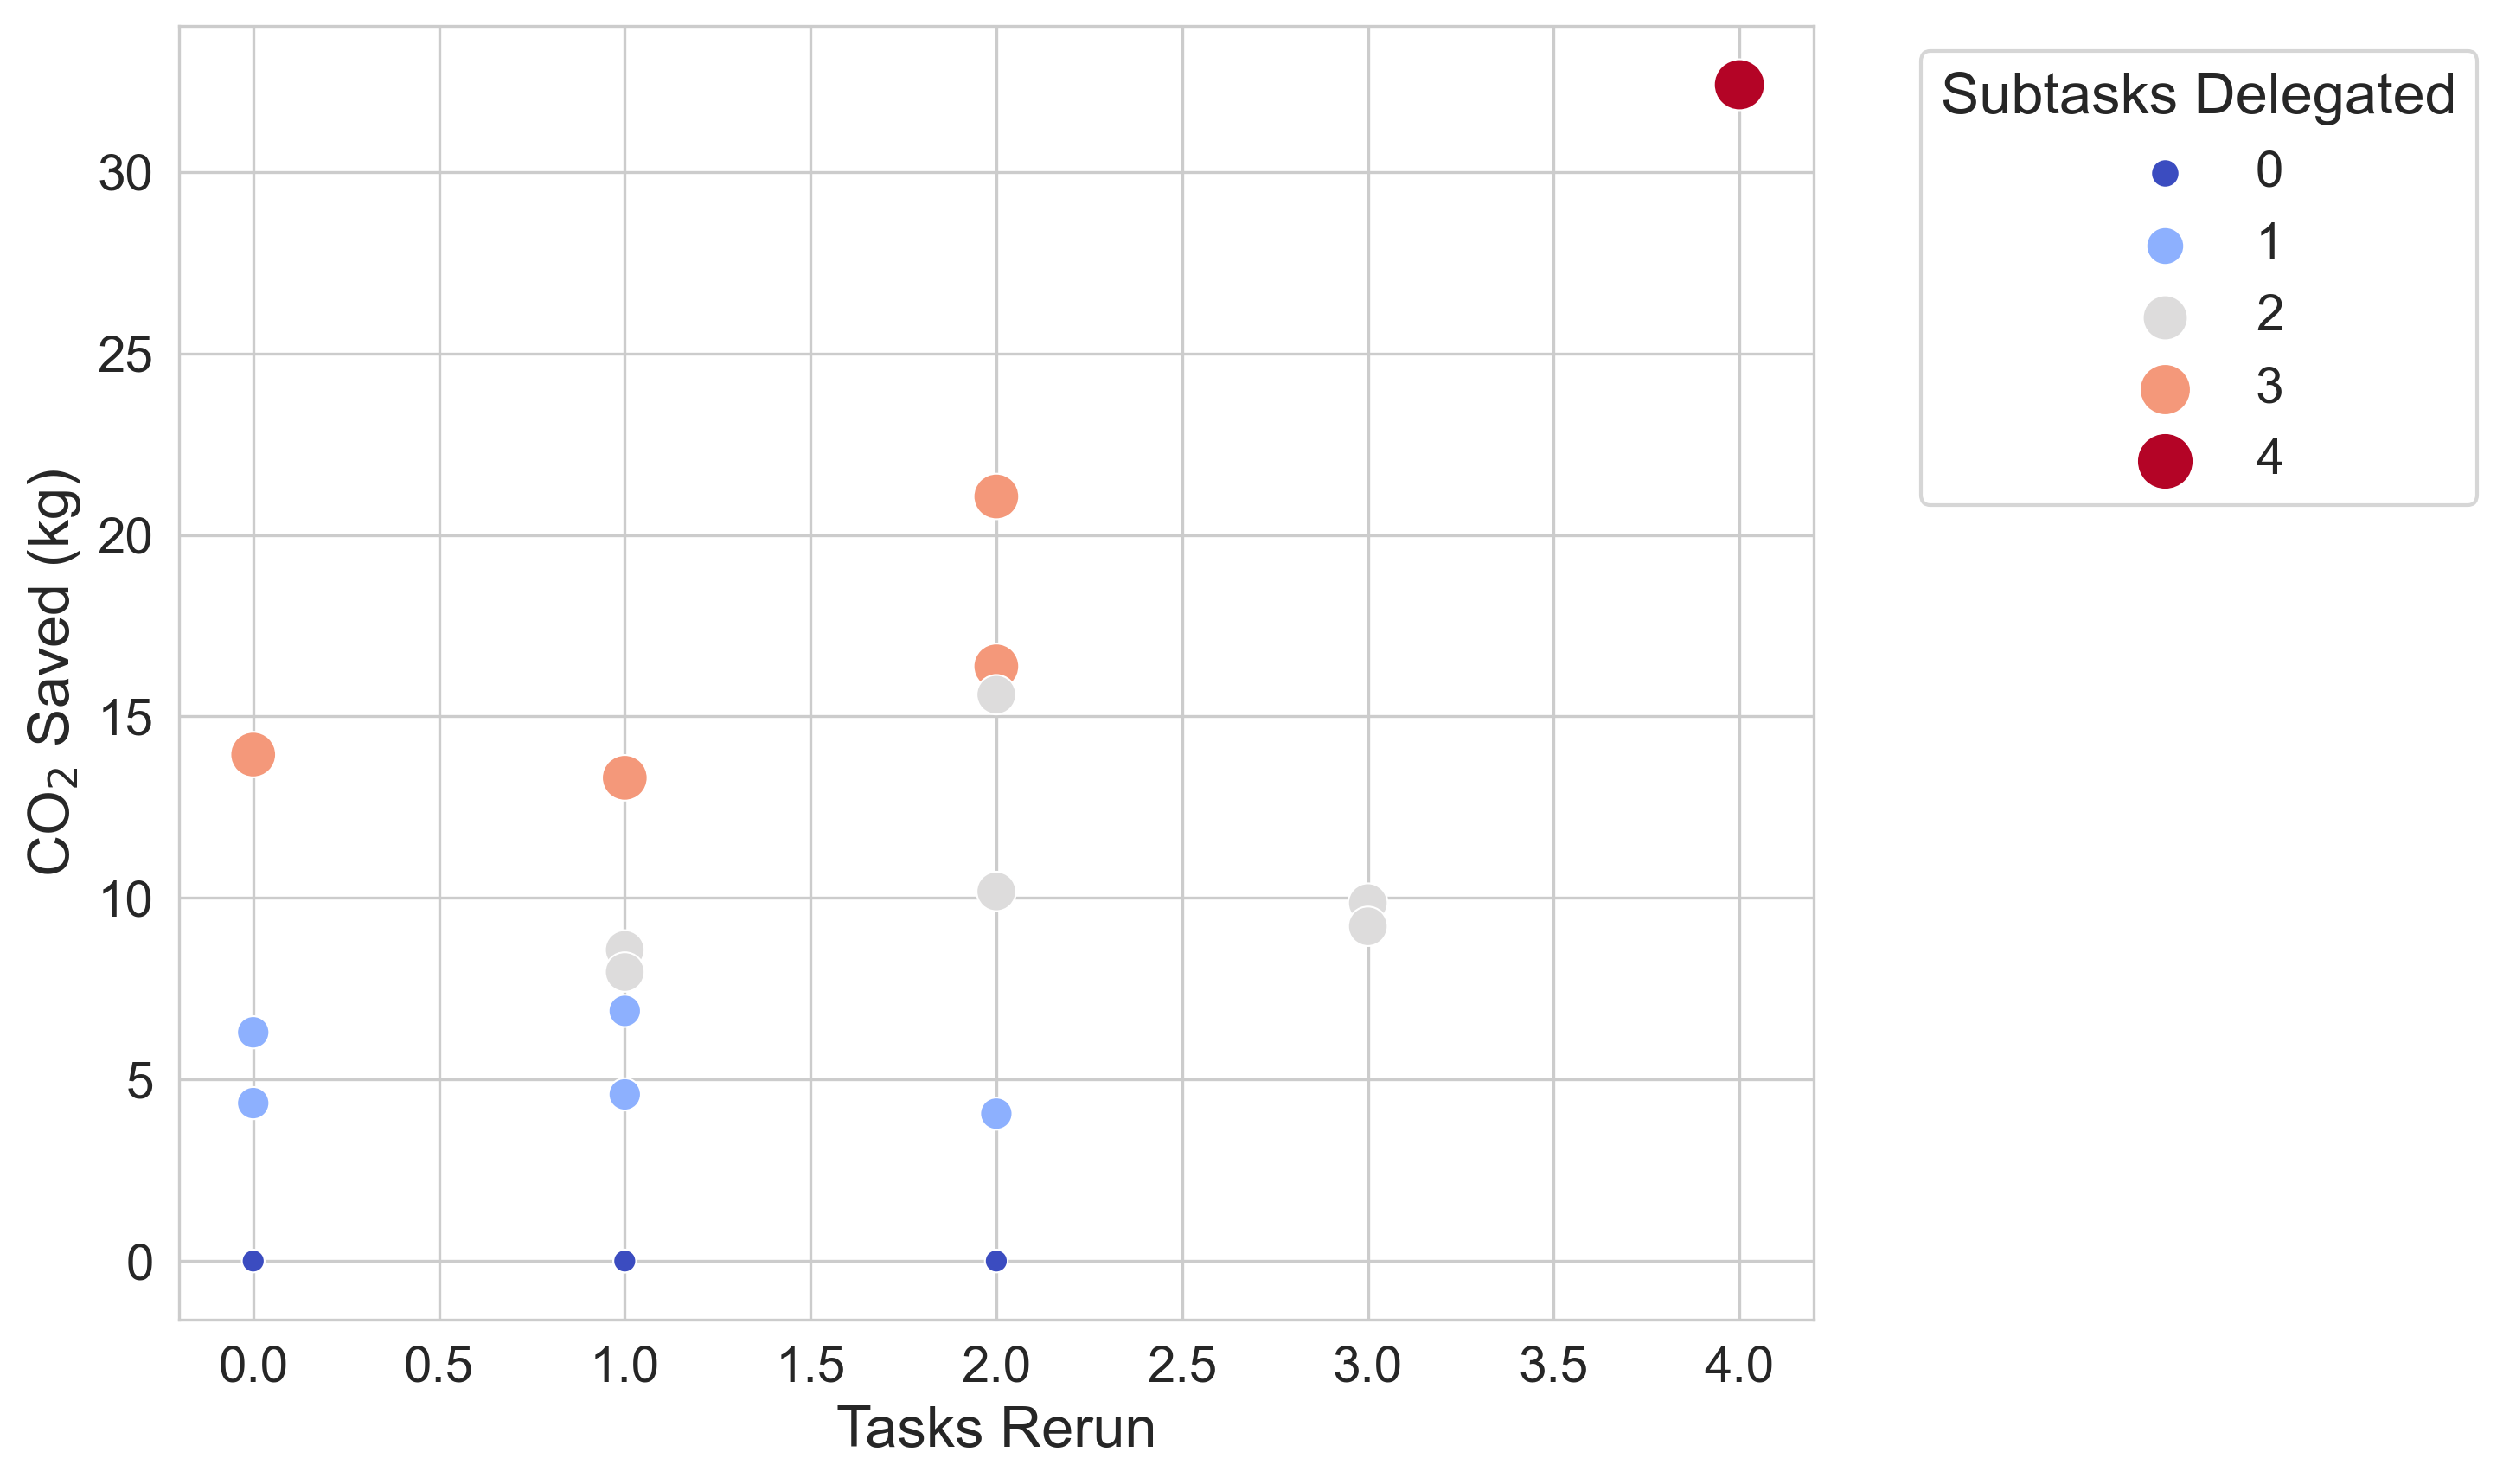

/var/folders/v6/43nstwv52771z0q7sjpfqzv00000gn/T/ipykernel_58522/1423788162.py:18: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  plt.tight_layout()
/Users/kayadetunji/anaconda3/envs/kaymacmini/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


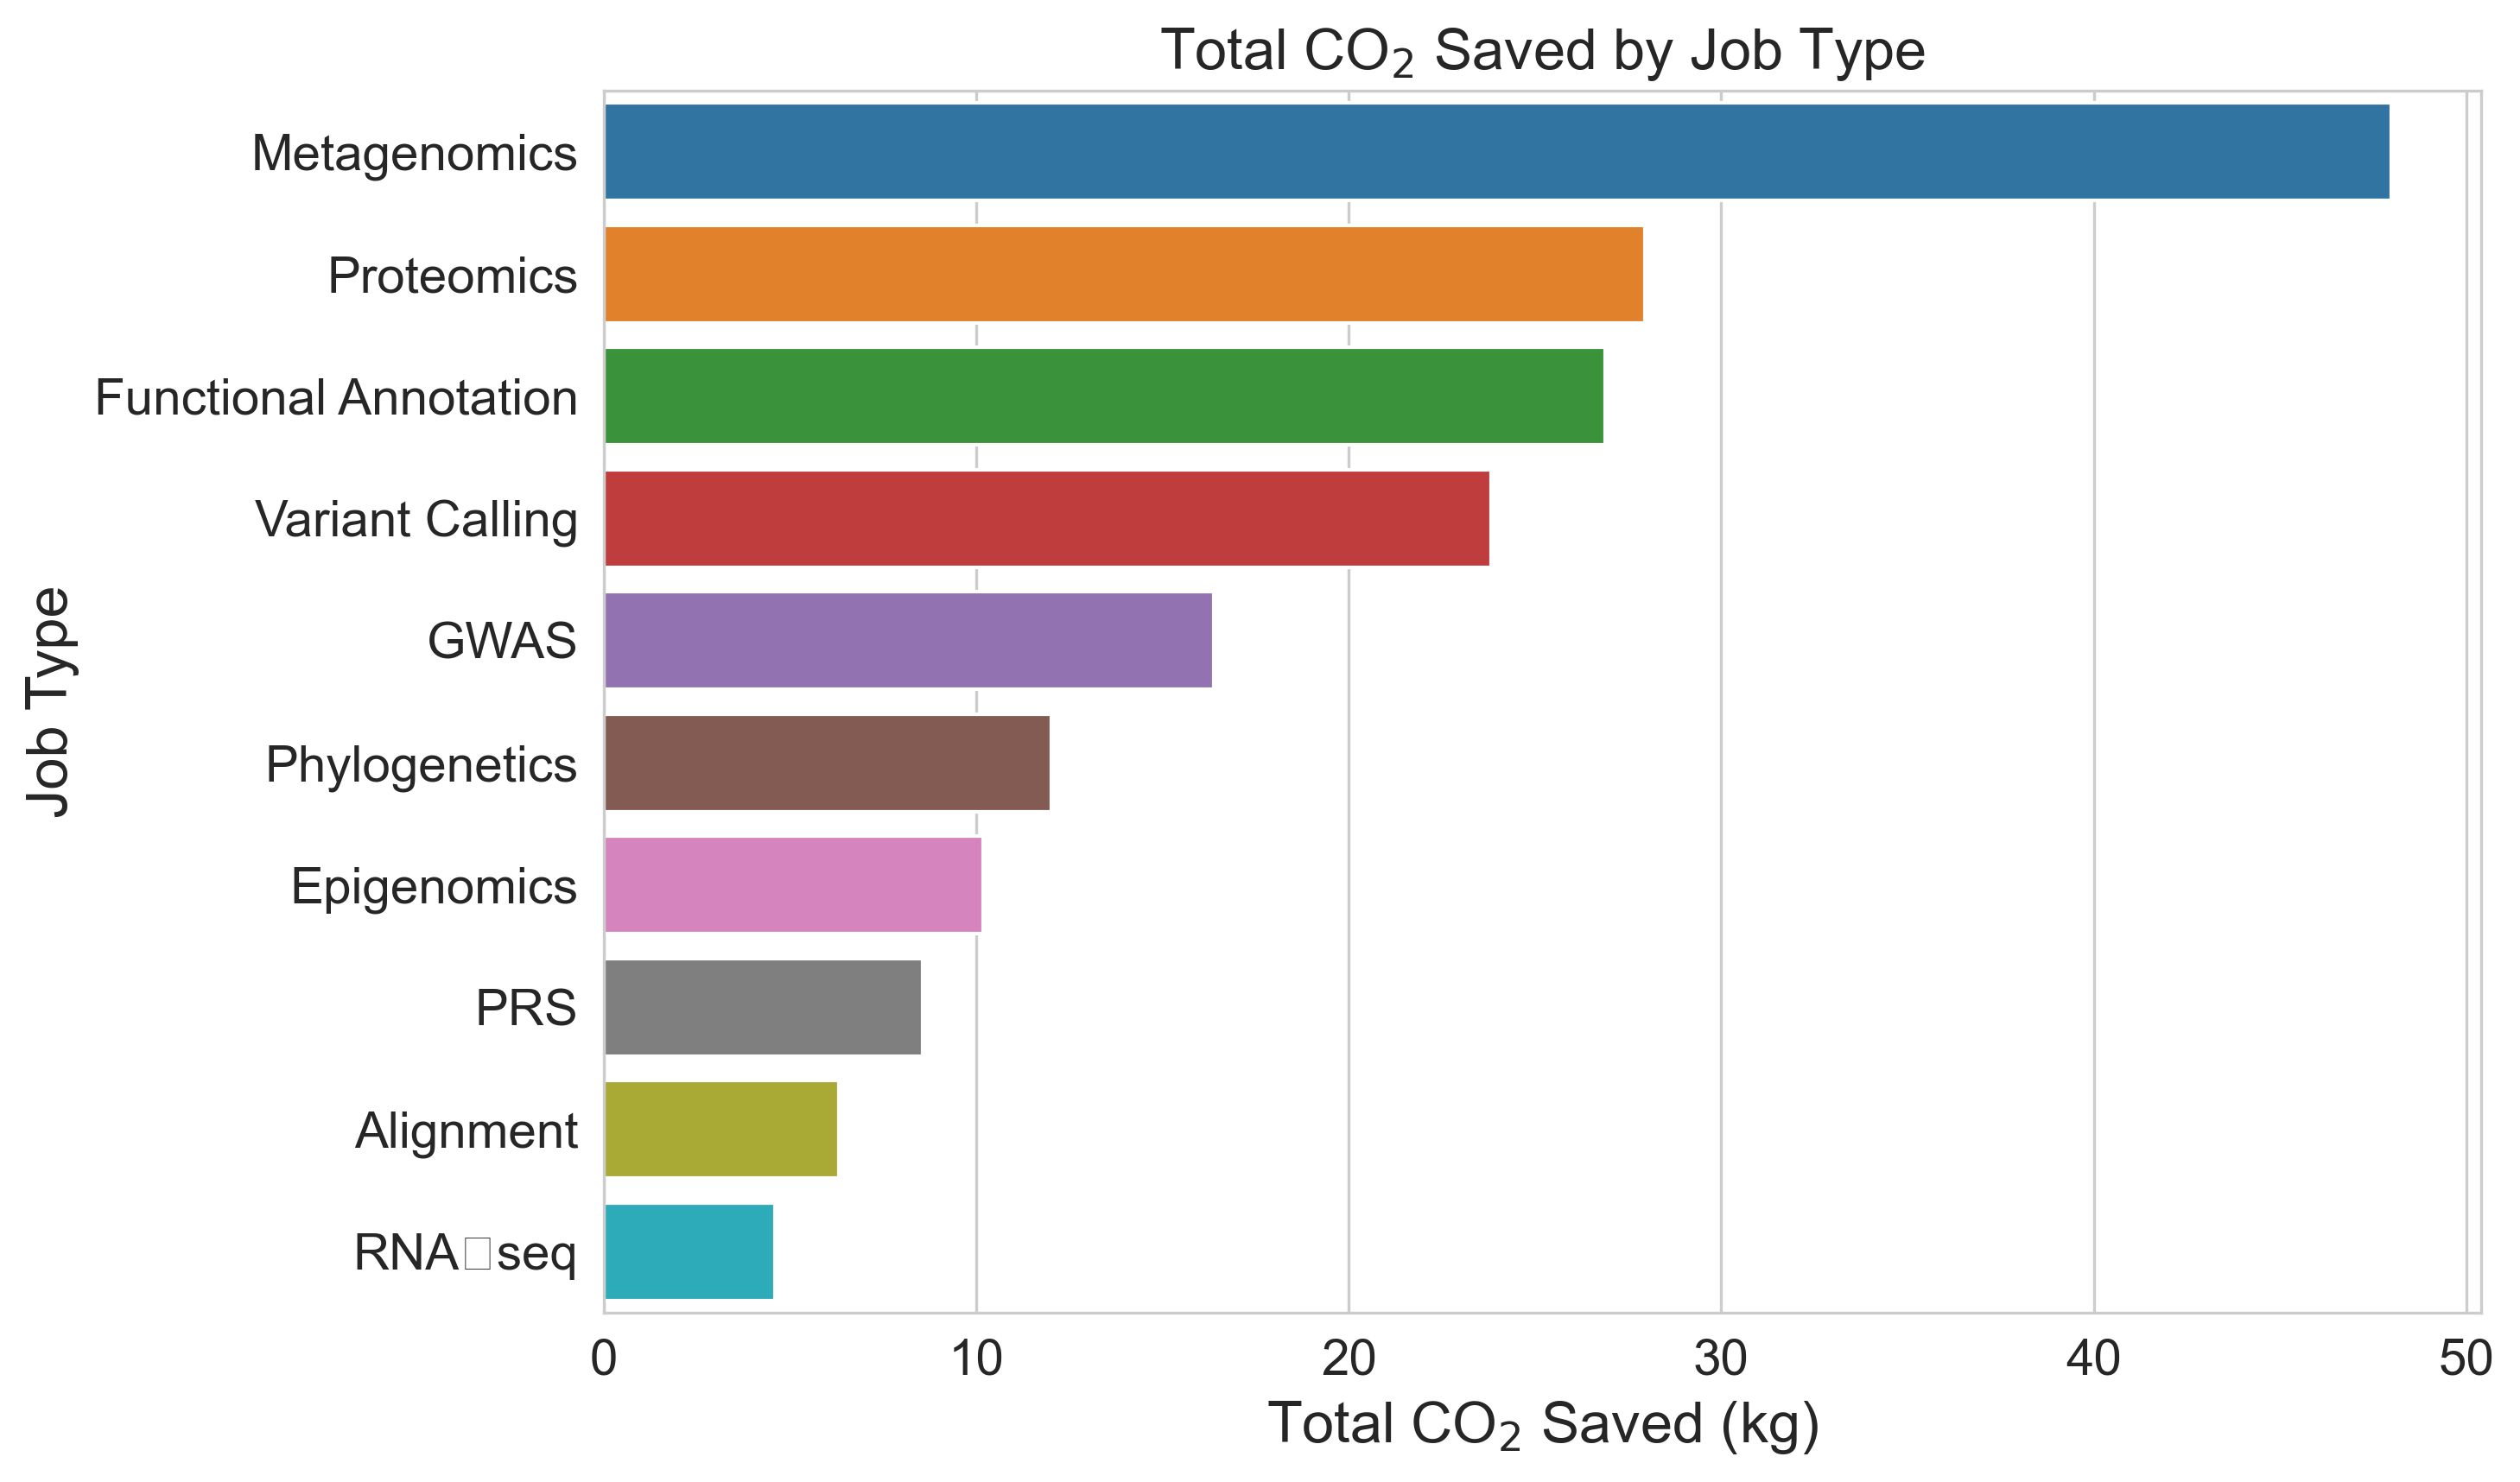

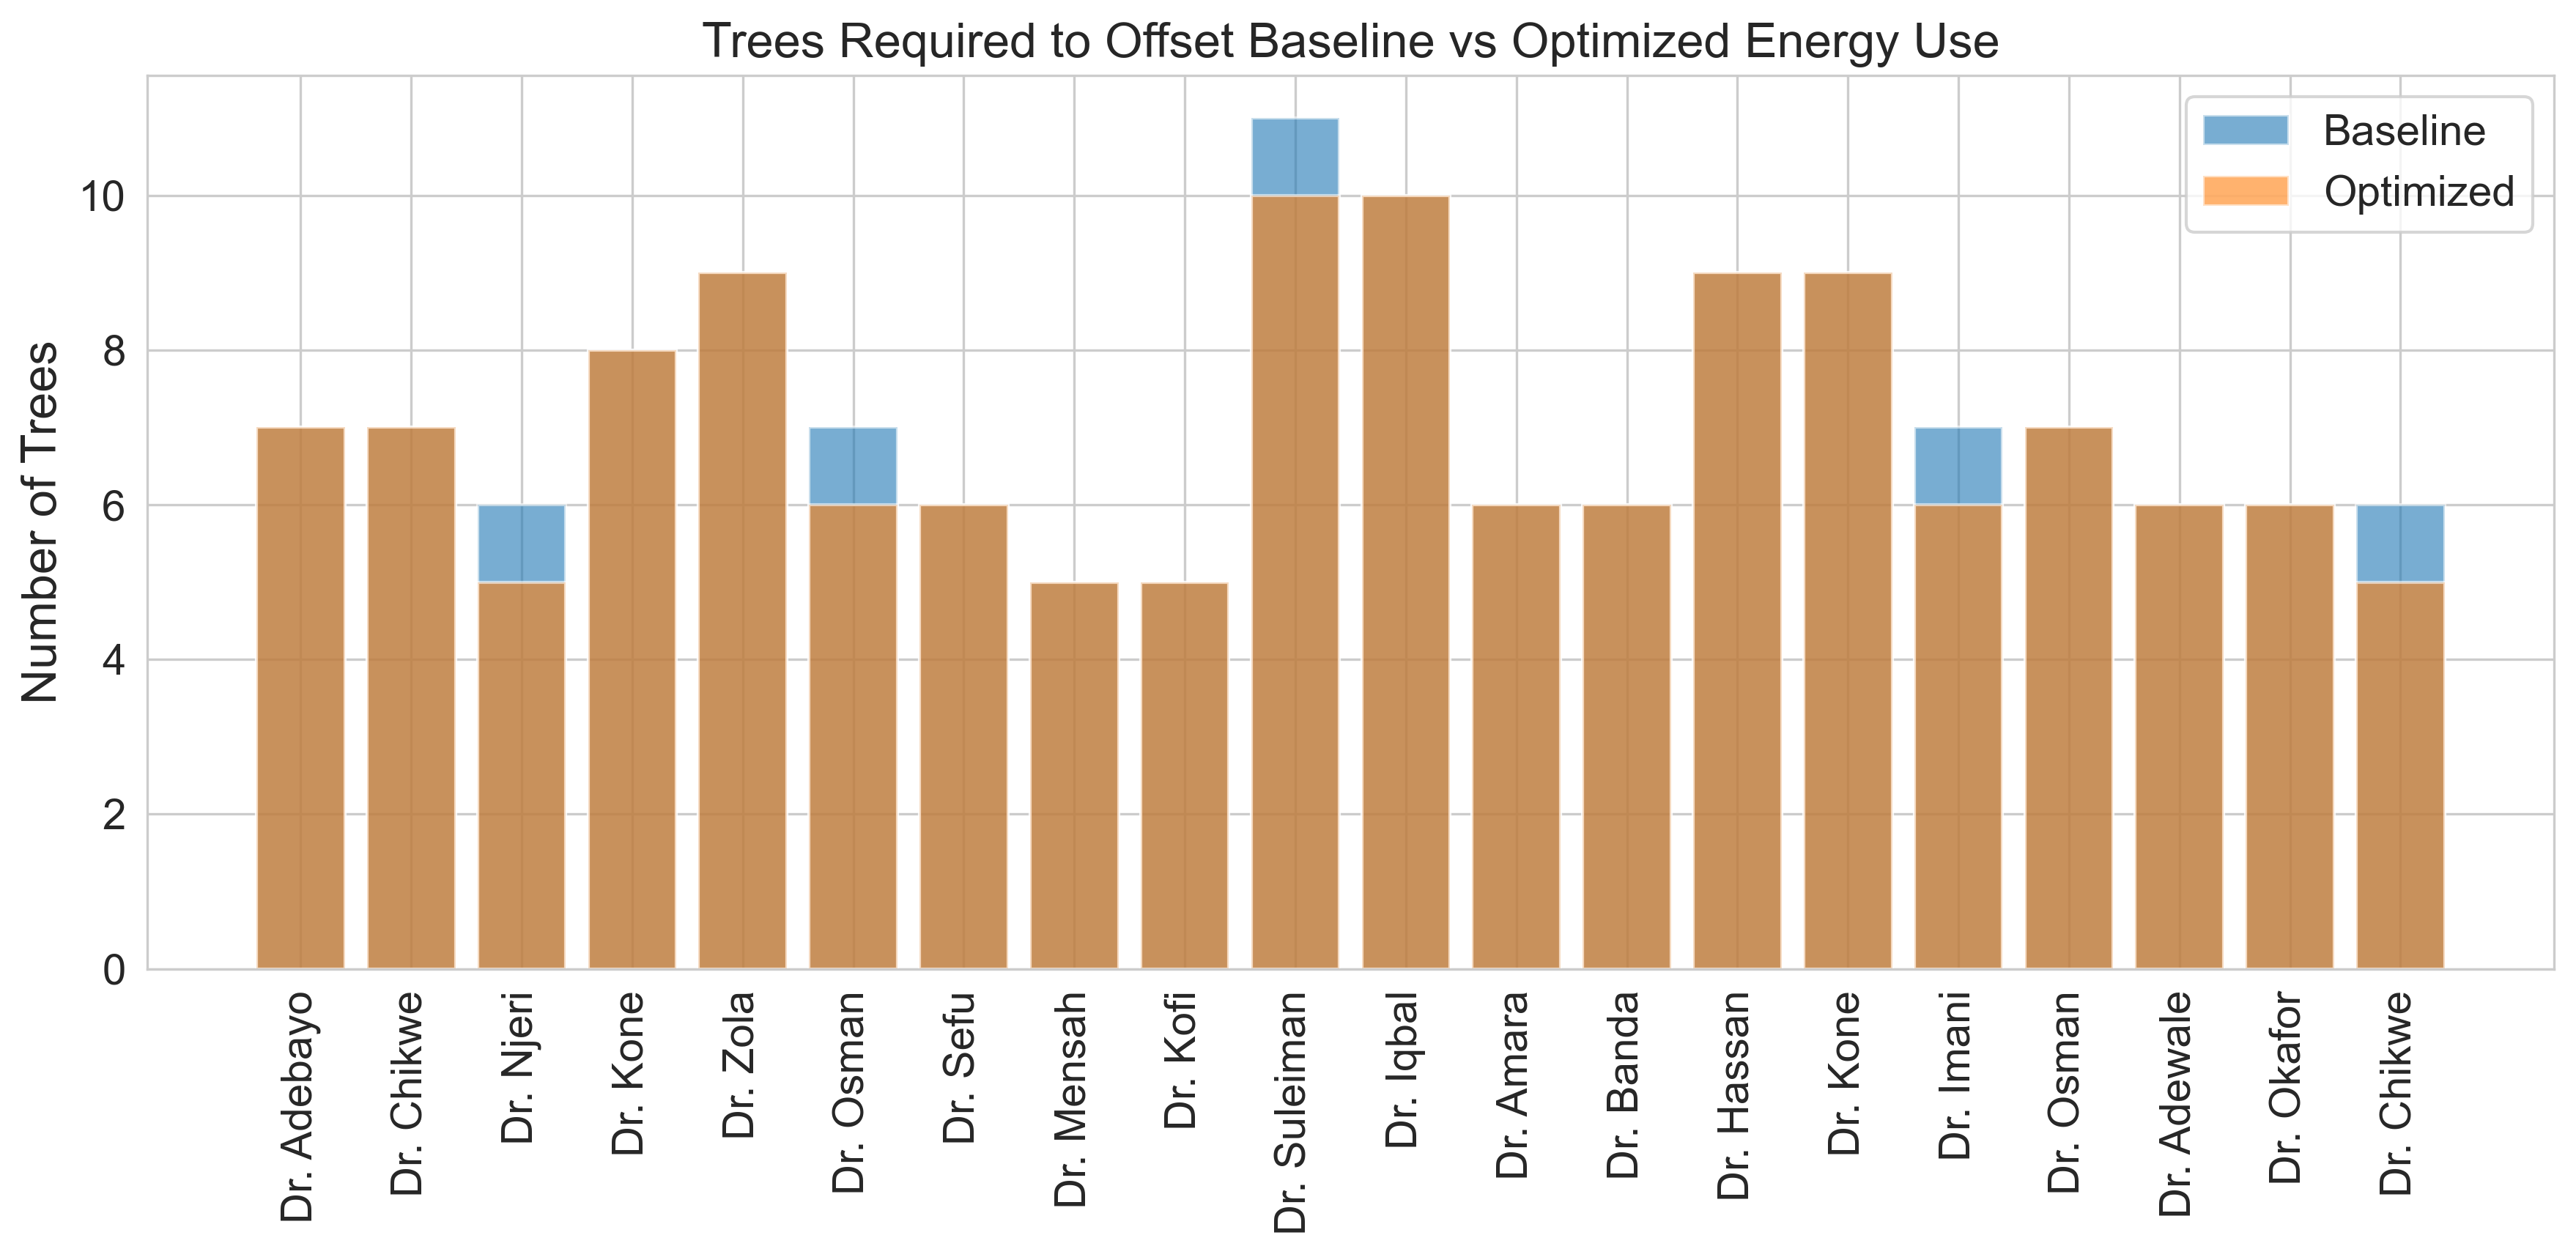

In [52]:
# 1. Delegation & Reruns vs. CO2 Saved
plt.figure(figsize=(10, 6), dpi=300)
sns.scatterplot(data=df, x="Tasks Rerun", y="CO2 Saved (kg)", hue="Subtasks Delegated", size="Subtasks Delegated", palette="coolwarm", sizes=(40, 200))
# plt.title("CO₂ Saved vs Tasks Rerun (Color/Size = Subtasks Delegated)")
plt.xlabel("Tasks Rerun")
plt.ylabel("CO$_2$ Saved (kg)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Subtasks Delegated')
plt.tight_layout()
plt.show()

# 2. CO2 Saved per Job Type
plt.figure(figsize=(10, 6), dpi=300)
jobtype_savings = df.groupby("Job Type")["CO2 Saved (kg)"].sum().sort_values(ascending=False)
sns.barplot(x=jobtype_savings.values, y=jobtype_savings.index)
plt.title("Total CO$_2$ Saved by Job Type")
plt.xlabel("Total CO$_2$ Saved (kg)")
plt.ylabel("Job Type")
plt.tight_layout()
plt.show()

# 3. Tree Offset Comparison: Baseline vs Optimized
plt.figure(figsize=(12, 6), dpi=300)
x = range(len(df))
plt.bar(x, df["Trees to Offset Baseline"], label="Baseline", alpha=0.6)
plt.bar(x, df["Trees to Offset Optimized"], label="Optimized", alpha=0.6)
plt.xticks(x, df["Researcher"], rotation=90)
plt.ylabel("Number of Trees")
plt.title("Trees Required to Offset Baseline vs Optimized Energy Use")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
features = df[["Tasks Rerun", "Subtasks Delegated", "Runtime Increase (%)"]]
target = df["CO2 Saved (kg)"]
features = sm.add_constant(features)
model = sm.OLS(target, features).fit()

# Summary table of regression model
summary_table = model.params.rename("Coefficient").to_frame()
summary_table["Description"] = [
    "Intercept",
    "Each additional task rerun",
    "Each additional subtask delegated",
    "Each 1% increase in runtime"
]
summary_table.reset_index(inplace=True)
summary_table.rename(columns={"index": "Variable"}, inplace=True)

In [17]:
summary_table

,Variable,Coefficient,Description
0,const,-2.214753,Intercept
1,Tasks Rerun,1.335830,Each additional task rerun
2,Subtasks Delegated,0.221720,Each additional subtask delegated
3,Runtime Increase (%),1.108601,Each 1% increase in runtime


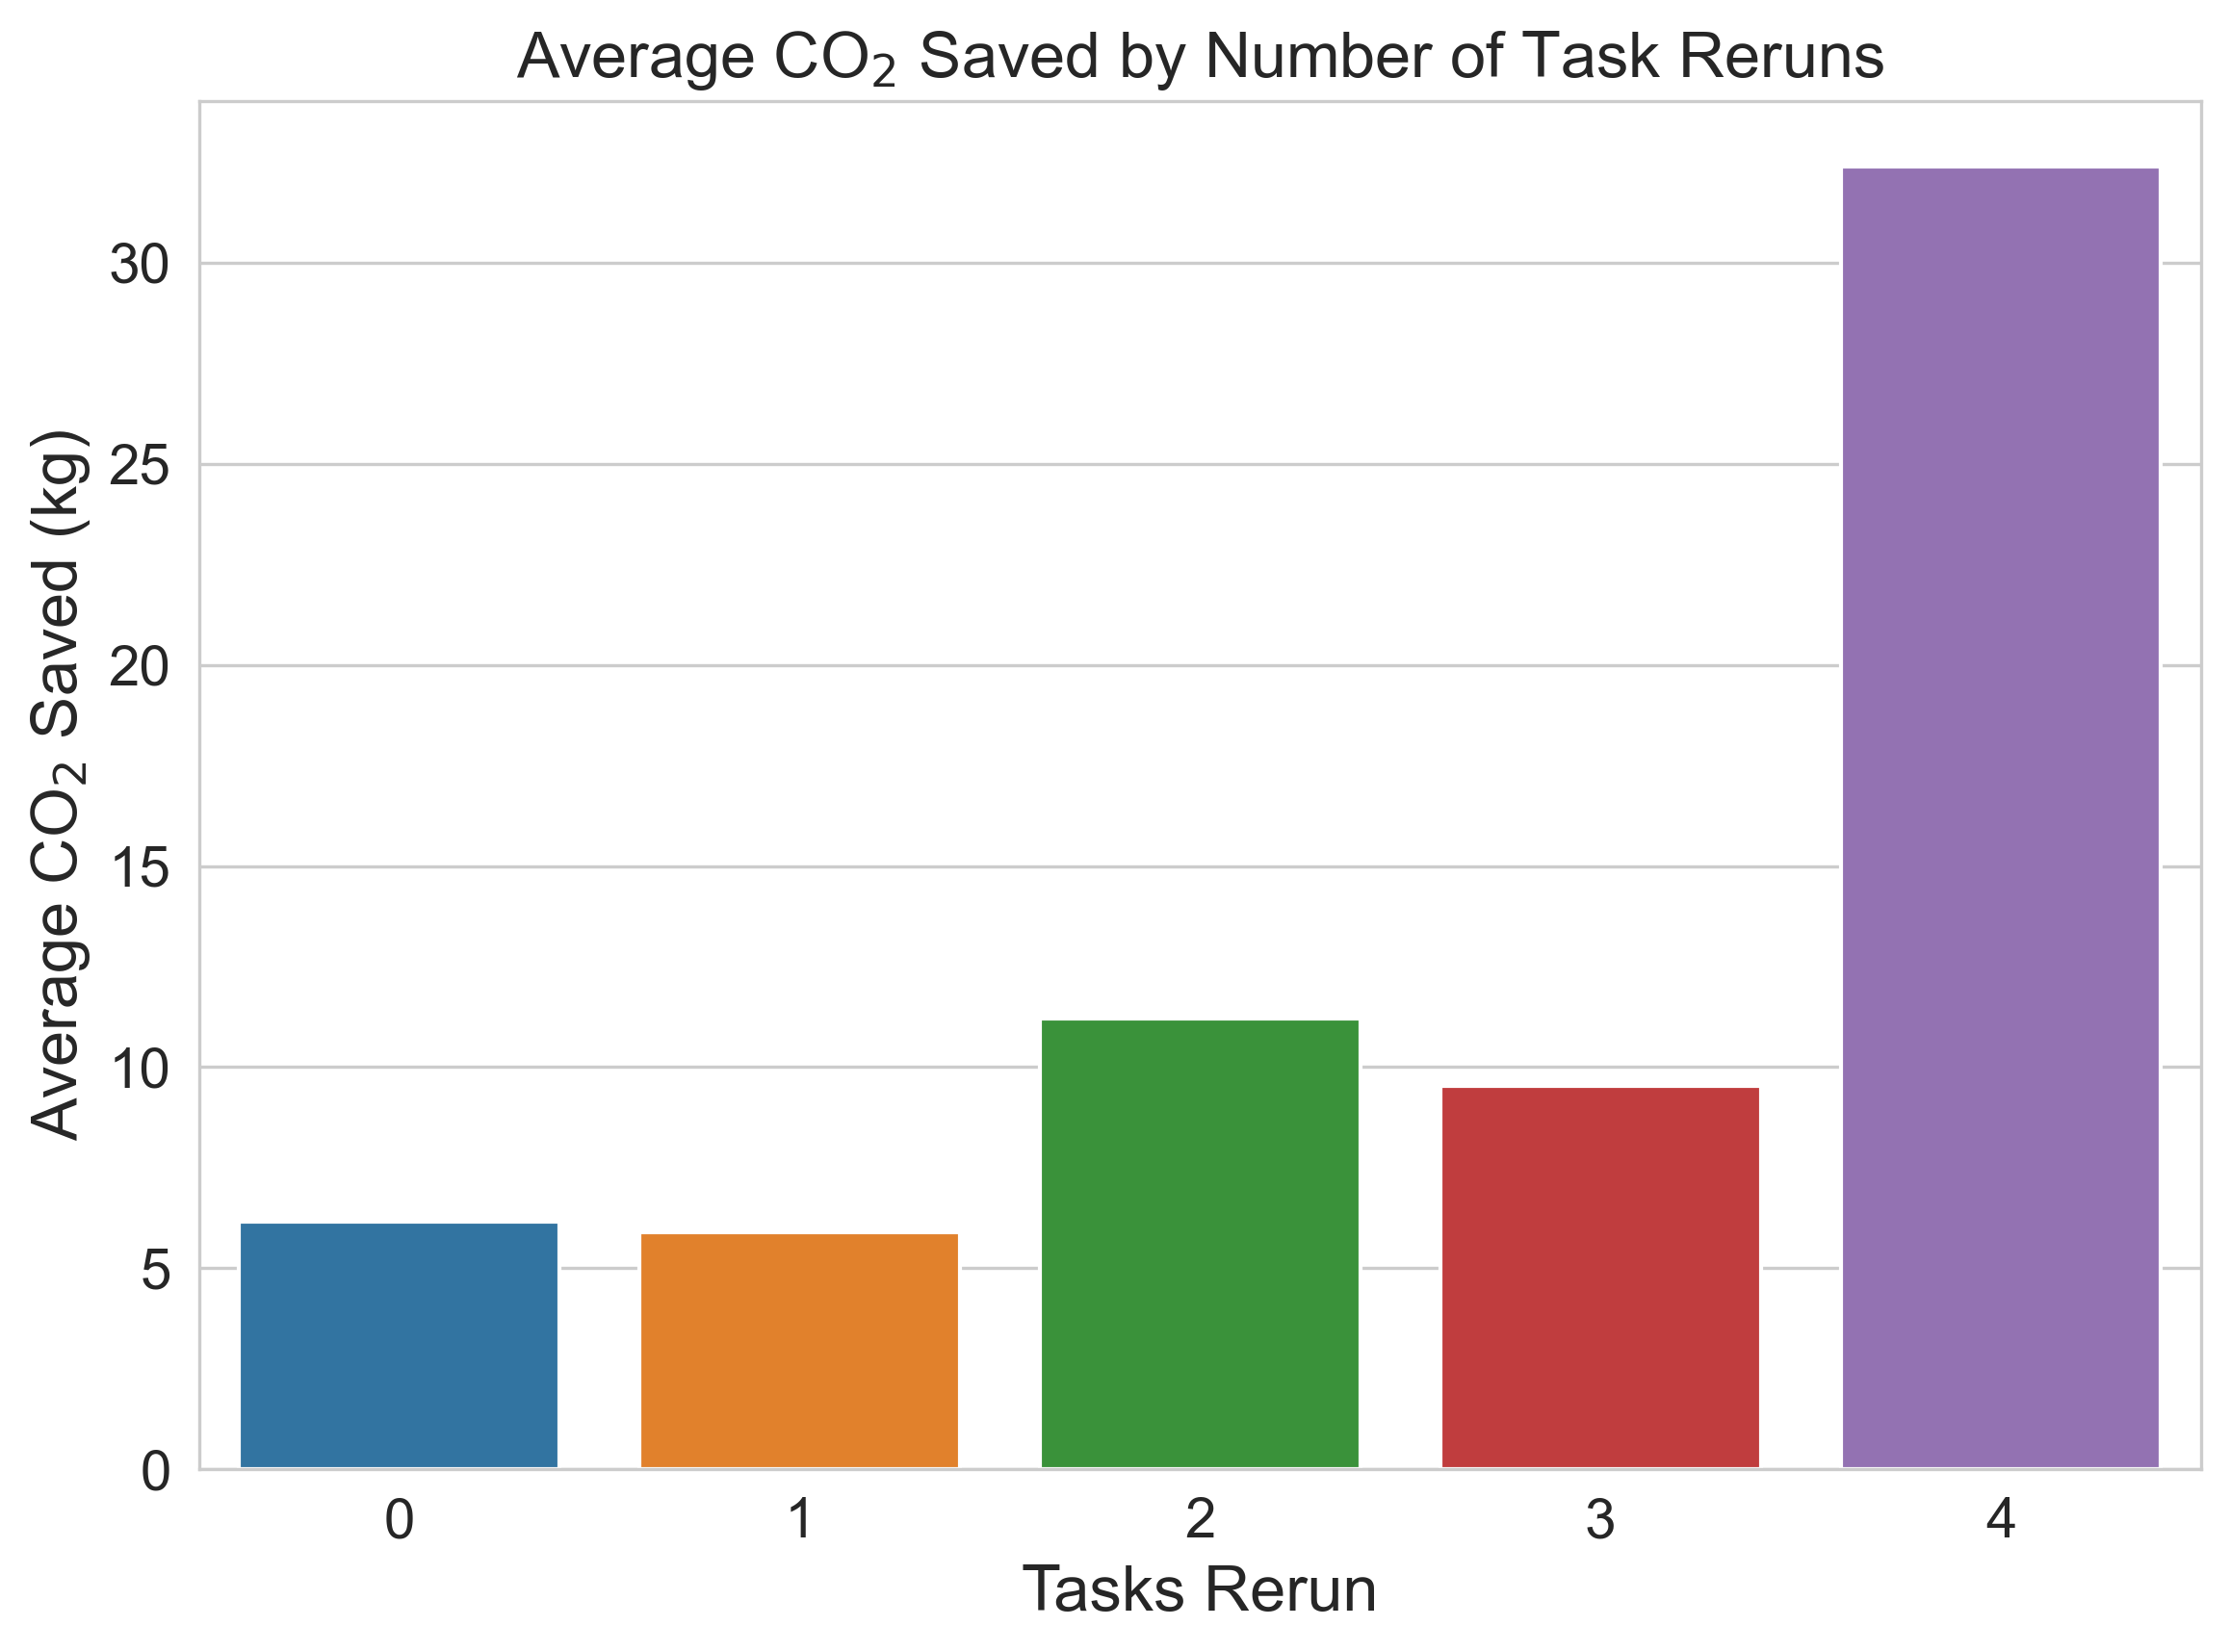

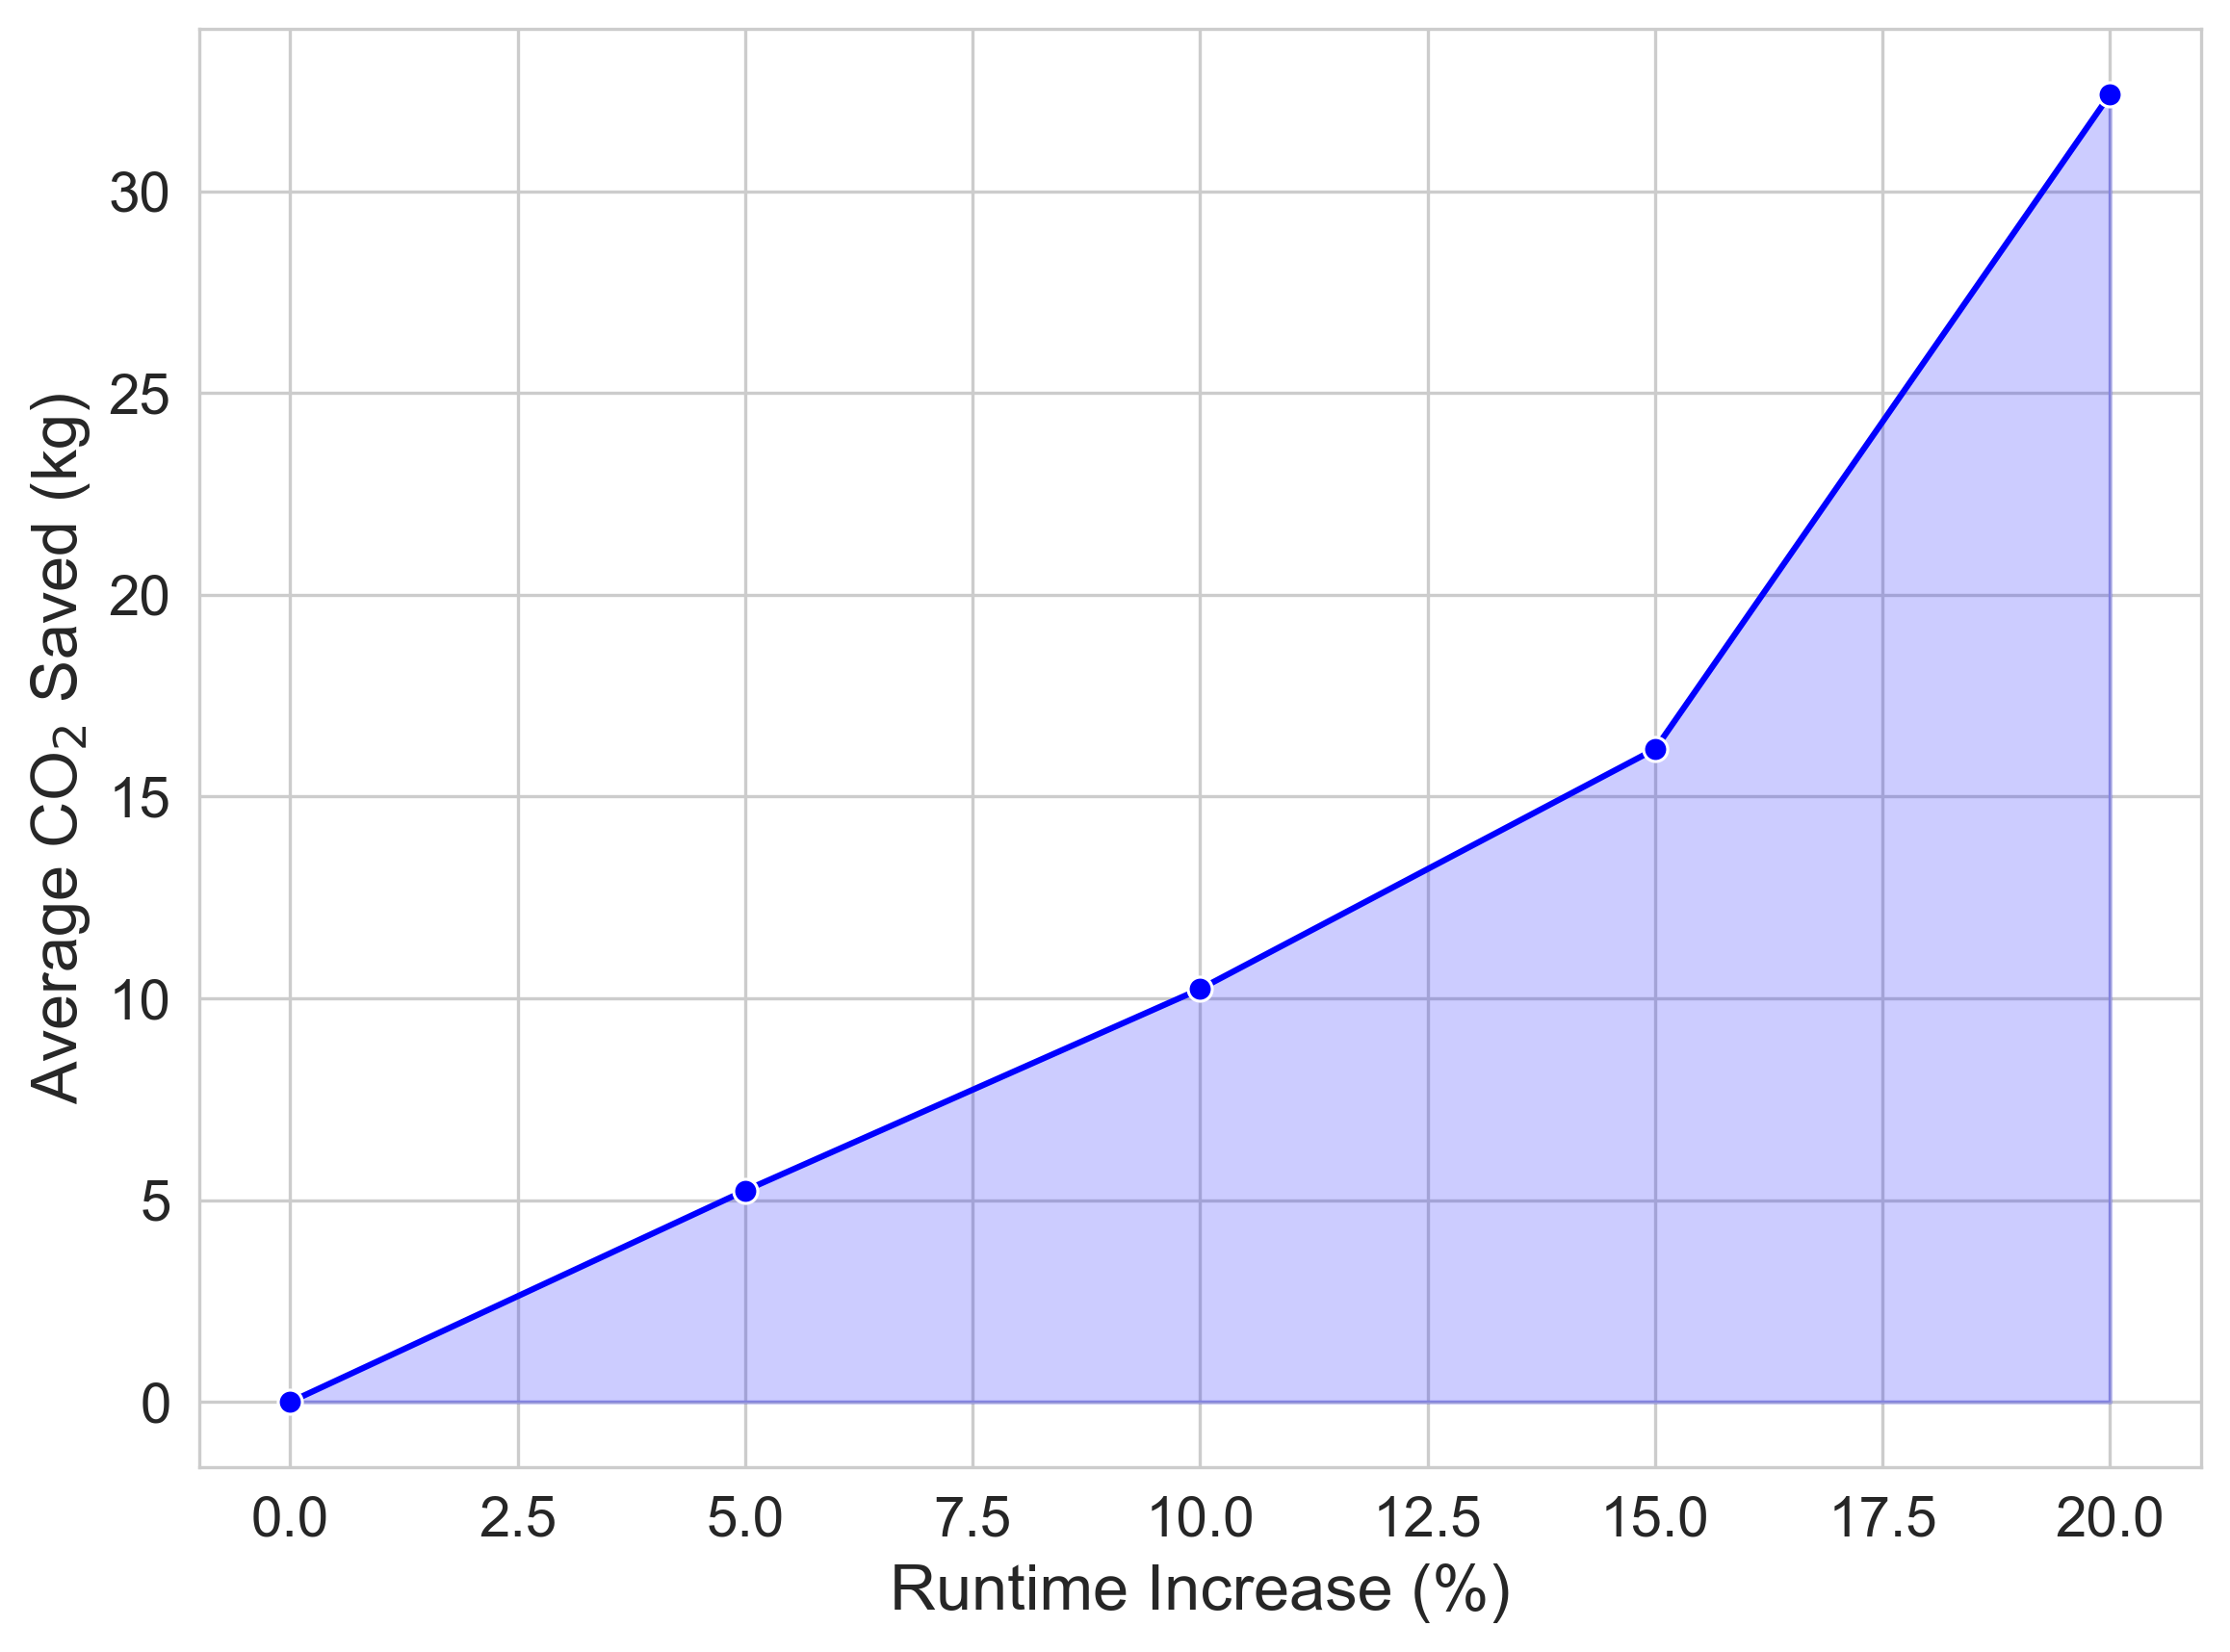

/var/folders/v6/43nstwv52771z0q7sjpfqzv00000gn/T/ipykernel_58522/1760534226.py:29: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  plt.tight_layout()
/Users/kayadetunji/anaconda3/envs/kaymacmini/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


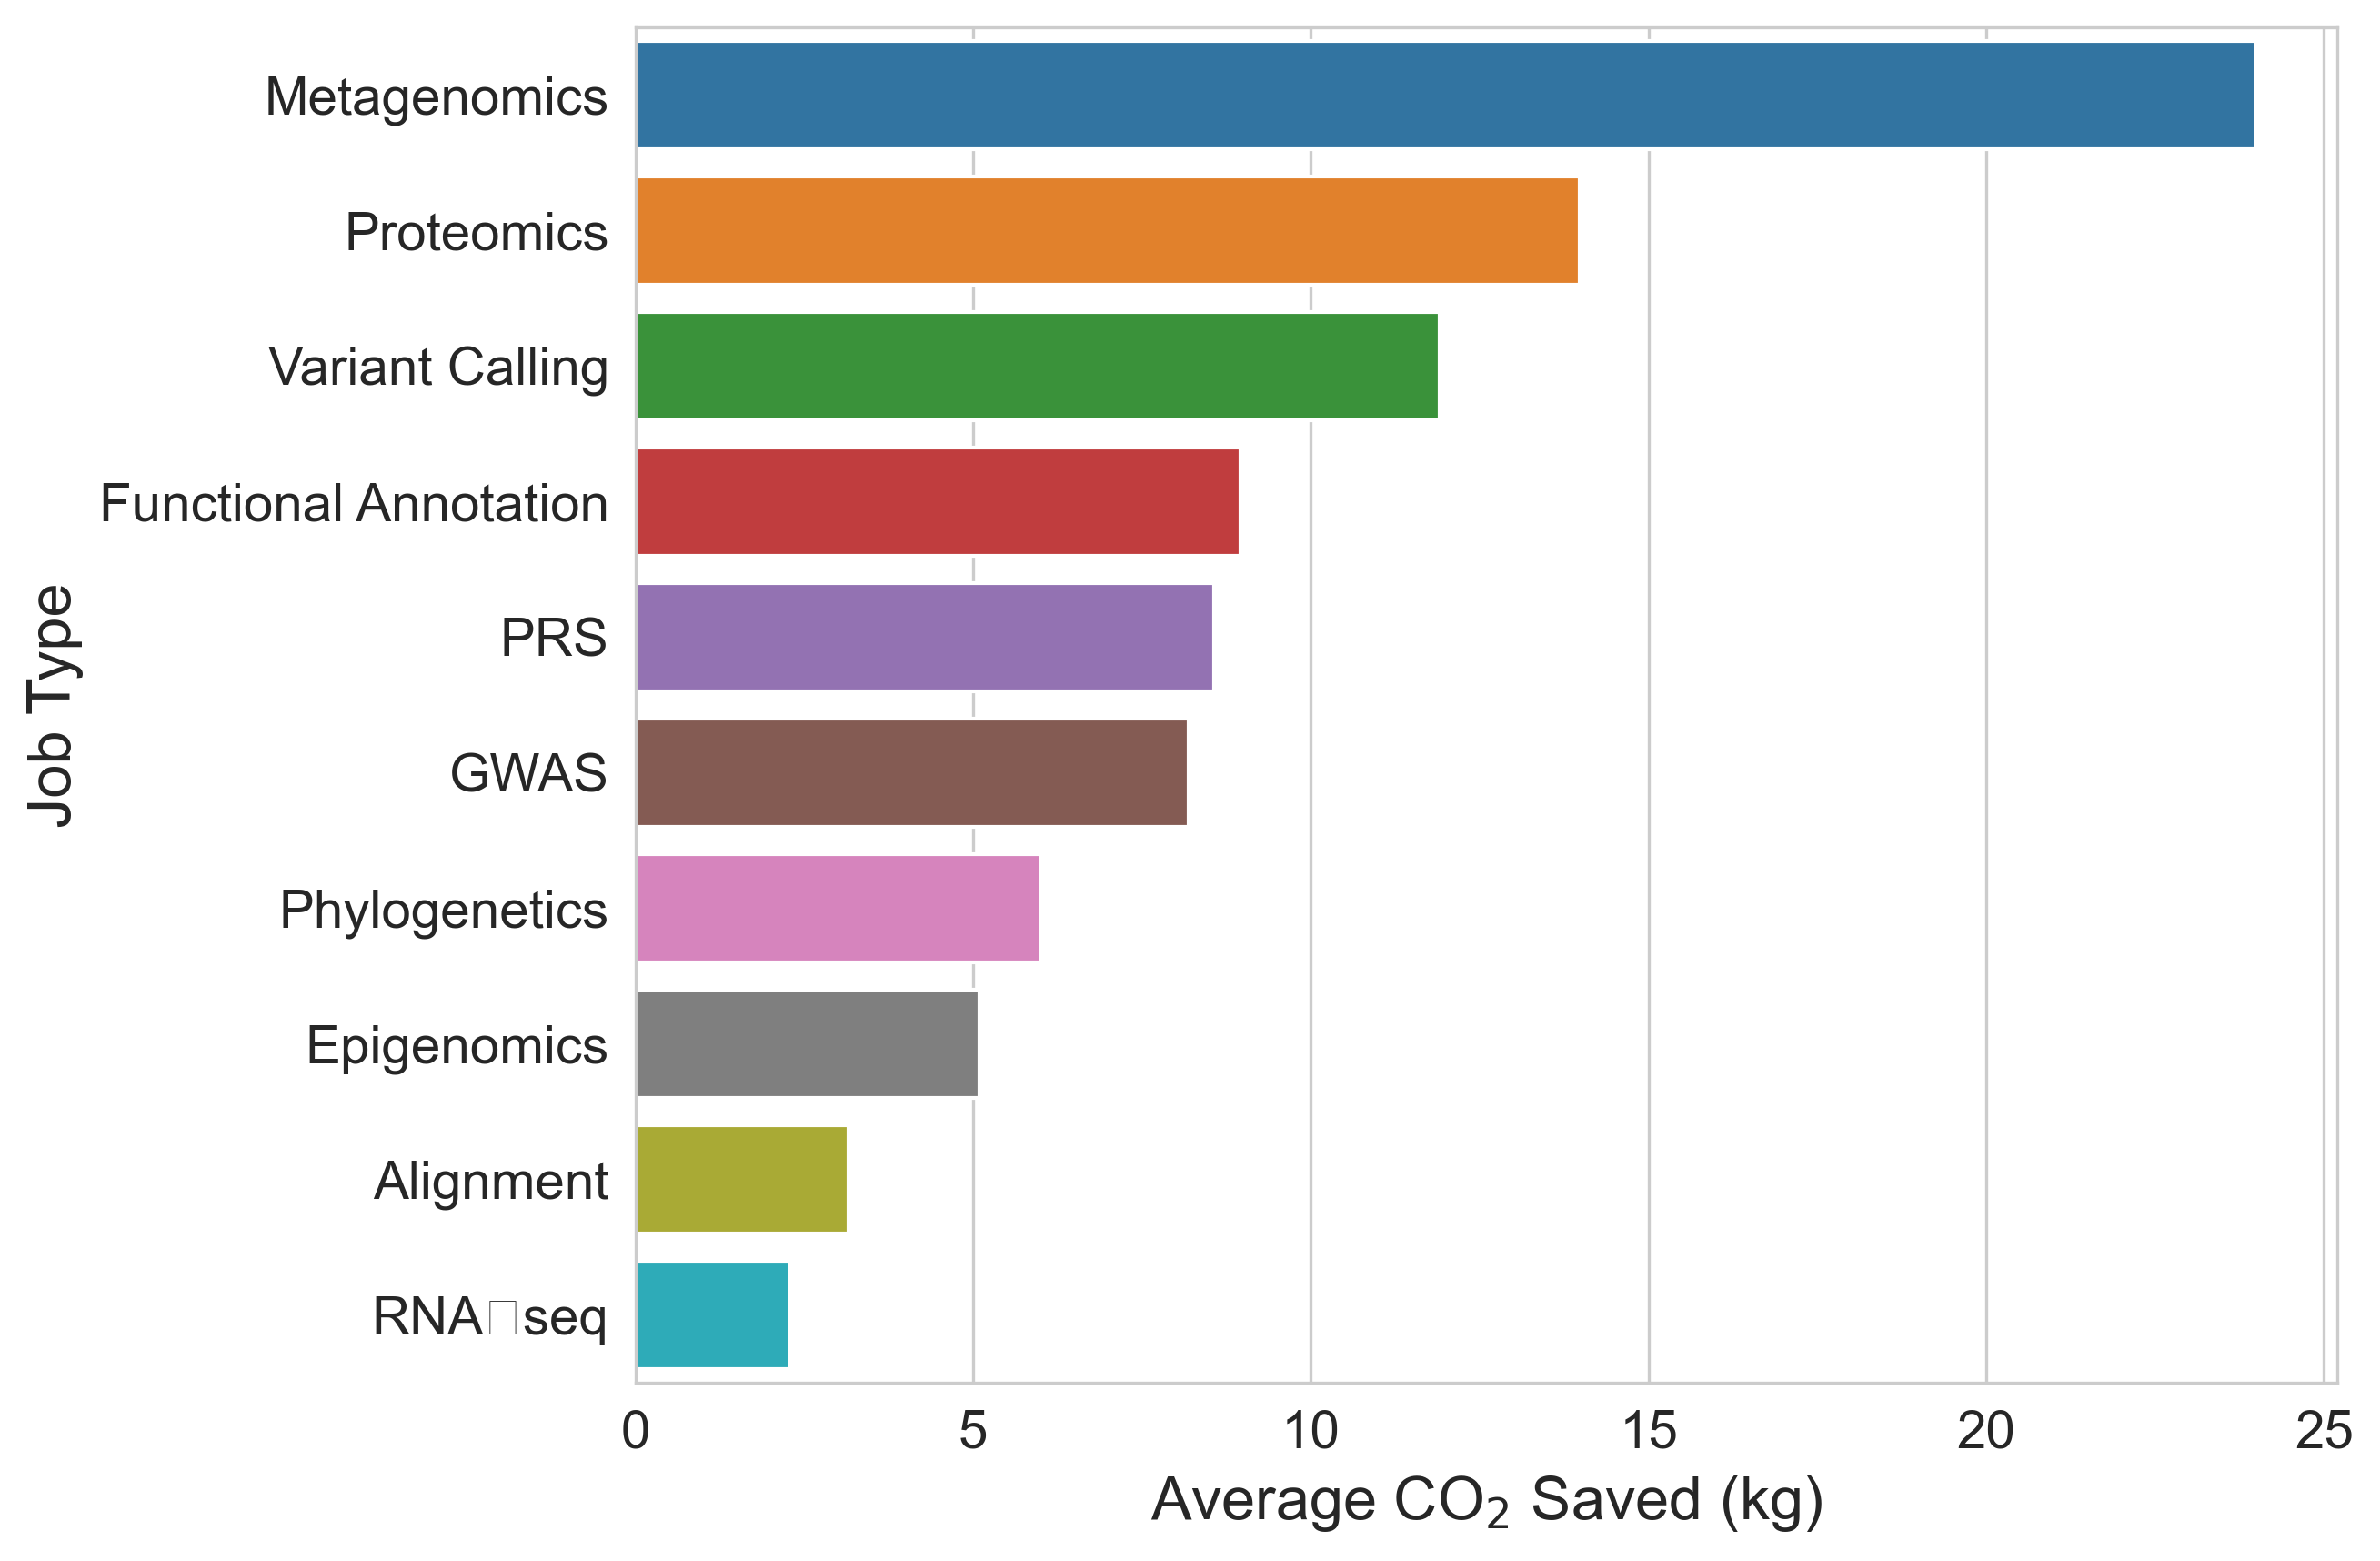

In [53]:
# 1. CO2 Saved by Task Reruns
plt.figure(figsize=(8, 6), dpi=300)
rerun_group = df.groupby("Tasks Rerun")["CO2 Saved (kg)"].mean().reset_index()
sns.barplot(data=rerun_group, x="Tasks Rerun", y="CO2 Saved (kg)")
plt.title("Average CO$_2$ Saved by Number of Task Reruns")
plt.ylabel("Average CO$_2$ Saved (kg)")
plt.xlabel("Tasks Rerun")
plt.tight_layout()
plt.show()

# 2. CO2 Saved vs Runtime Increase
plt.figure(figsize=(8, 6), dpi=300)
runtime_group = df.groupby("Runtime Increase (%)")["CO2 Saved (kg)"].mean().reset_index()
sns.lineplot(data=runtime_group, x="Runtime Increase (%)", y="CO2 Saved (kg)", marker="o", color="blue")
plt.fill_between(runtime_group["Runtime Increase (%)"], runtime_group["CO2 Saved (kg)"], alpha=0.2, color="blue")
# plt.title("CO$_2$ Saved vs Runtime Increase")
plt.ylabel("Average CO$_2$ Saved (kg)")
plt.xlabel("Runtime Increase (%)")
plt.tight_layout()
plt.show()

# 3. Average CO2 Saved by Job Type
plt.figure(figsize=(9, 6), dpi=300)
job_group = df.groupby("Job Type")["CO2 Saved (kg)"].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=job_group, y="Job Type", x="CO2 Saved (kg)")
# plt.title("Average CO$_2$ Saved by Workflow Type")
plt.xlabel("Average CO$_2$ Saved (kg)")
plt.ylabel("Job Type")
plt.tight_layout()
plt.show()

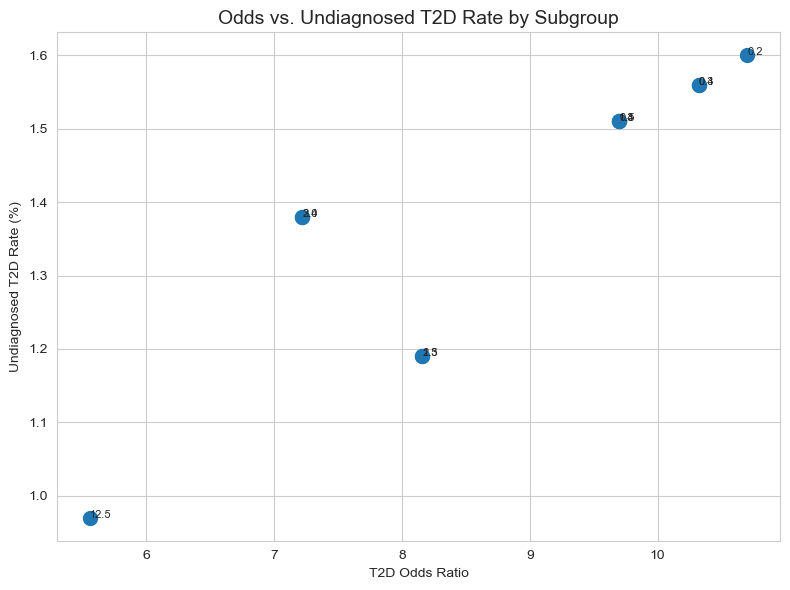

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Create the DataFrame from the provided data
data = {
    "Penalty": [0.2, 0.3, 0.4, 0.5, 1.3, 1.4, 1.5, 2.3, 2.4, 3.0, 12.5],
    "Literals": [20, 13, 13, 7, 7, 7, 4, 4, 2, 2, 1],
    "Size": [188, 192, 192, 199, 199, 199, 252, 252, 290, 290, 412],
    "Size (%)": [7.56, 7.72, 7.72, 8.0, 8.0, 8.0, 10.14, 10.14, 11.67, 11.67, 16.57],
    "Odds": [10.7, 10.32, 10.32, 9.7, 9.7, 9.7, 8.16, 8.16, 7.22, 7.22, 5.56],
    "DM rate (%)": [35.68, 35.68, 35.68, 35.68, 35.68, 35.68, 39.44, 39.44, 41.31, 41.31, 46.95],
    "Undiag_T2D (%)": [1.6, 1.56, 1.56, 1.51, 1.51, 1.51, 1.19, 1.19, 1.38, 1.38, 0.97],
}

df = pd.DataFrame(data)
# Convert 'Penalty' to a categorical variable
# df["Penalty"] = pd.Categorical(df["Penalty"], ordered=True)
# # Sort the DataFrame by 'Penalty'
# df.sort_values("Penalty", inplace=True)
# Create a scatter plot: Odds vs. Undiagnosed %
plt.figure(figsize=(8, 6))
plt.scatter(df["Odds"], df["Undiag_T2D (%)"], s=100)

for i, txt in enumerate(df["Penalty"]):
    plt.annotate(txt, (df["Odds"][i], df["Undiag_T2D (%)"][i]), fontsize=8)

plt.title("Odds vs. Undiagnosed T2D Rate by Subgroup")
plt.xlabel("T2D Odds Ratio")
plt.ylabel("Undiagnosed T2D Rate (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

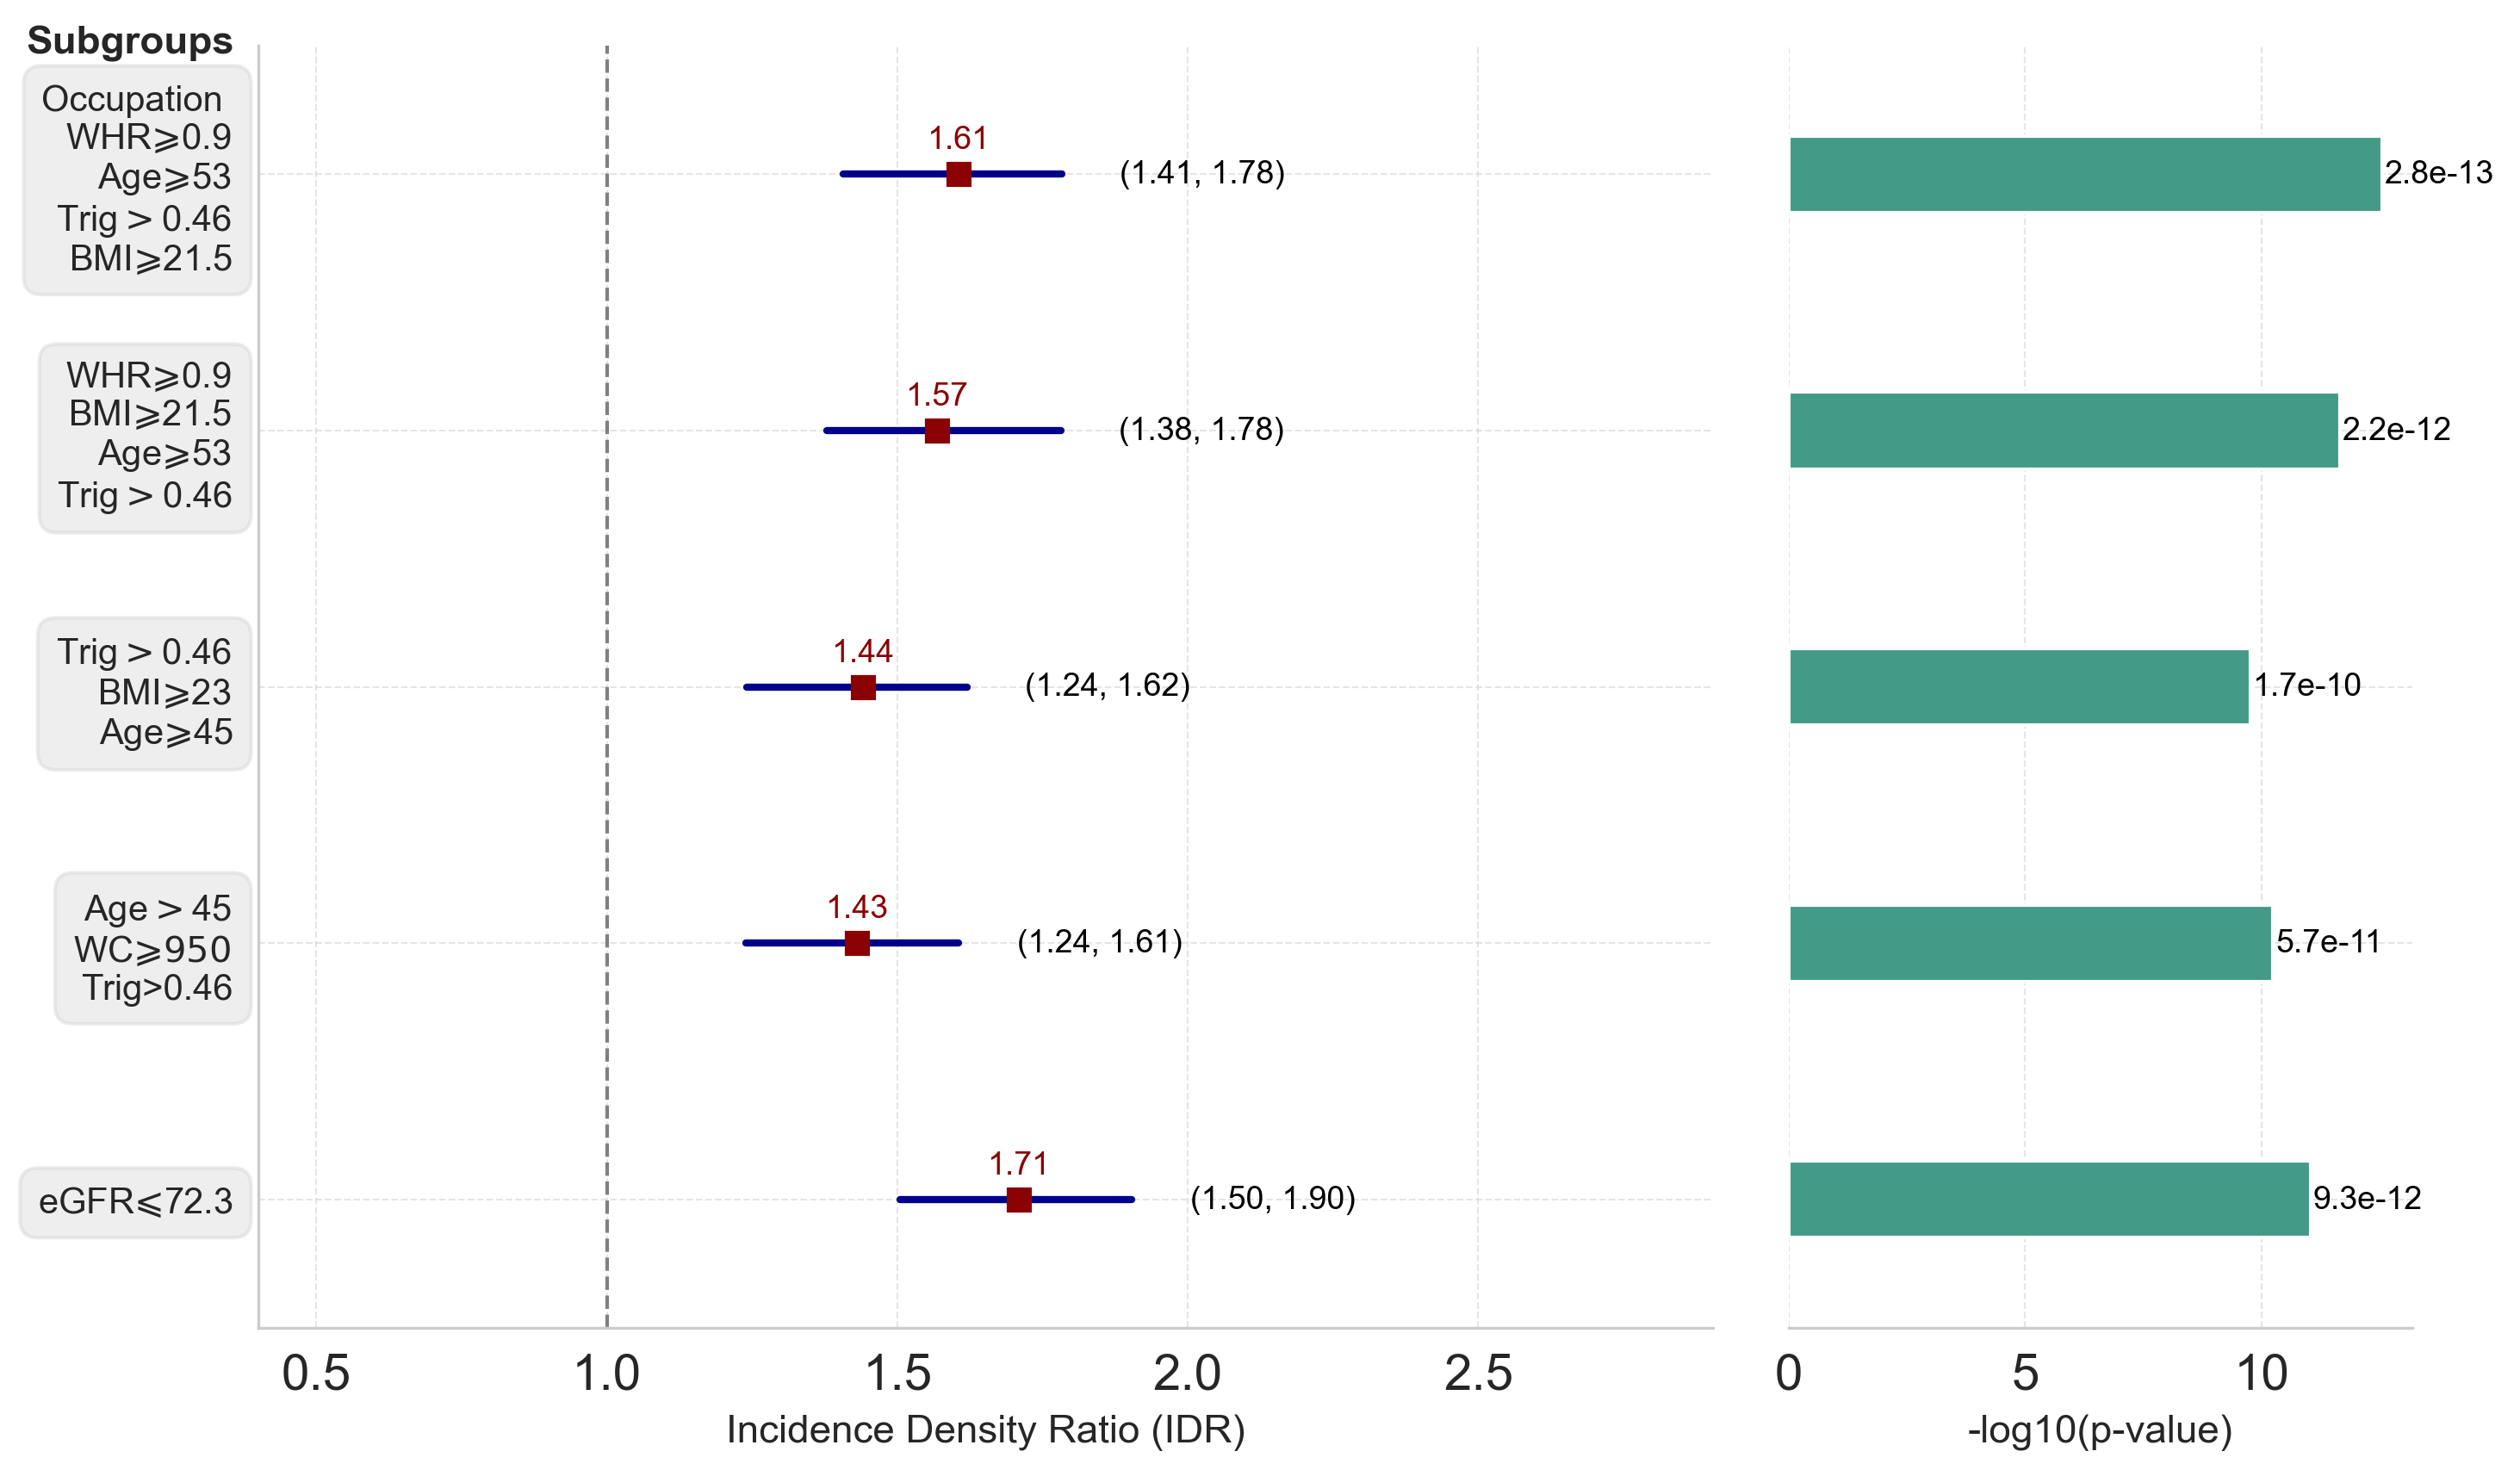

In [82]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Agincourt data (simplified for plot)
data_agincourt = pd.DataFrame({
    "label": [
        "Occupation \nWHR$\geqslant$0.9 \nAge$\geqslant$53 \nTrig$>$0.46 \nBMI$\geqslant$21.5",
        "WHR$\geqslant$0.9 \nBMI$\geqslant$21.5 \nAge$\geqslant$53 \nTrig$>$0.46",
        "Trig$>$0.46 \nBMI$\geqslant$23 \nAge$\geqslant$45",
        "Age$>$45 \nWC$\geqslant950$ \nTrig>0.46",
        "eGFR$\leqslant$72.3"
    ],
    "IDR": [1.606, 1.569, 1.441, 1.431, 1.71],
    "p-value": [2.76e-13, 2.21e-12, 1.73e-10, 5.67e-11, 9.26e-12]
})

# Compute mock confidence intervals (±12% of IDR for variability)
data_agincourt["CI_lower"] = data_agincourt["IDR"] * np.random.uniform(0.86, 0.89, size=len(data_agincourt))
data_agincourt["CI_upper"] = data_agincourt["IDR"] * np.random.uniform(1.11, 1.14, size=len(data_agincourt))

# Reverse for plotting (top to bottom)
data_agincourt = data_agincourt.iloc[::-1].reset_index(drop=True)
y_positions = np.arange(len(data_agincourt))
n_groups = len(data_agincourt)

# Plot
fig, (ax_forest, ax_pvals) = plt.subplots(
    1, 2, 
    figsize=(10, 6),
    gridspec_kw={"width_ratios": [2.8, 1.2]}, dpi=300
)

# Forest plot
for i, row in data_agincourt.iterrows():
    ax_forest.plot([row["CI_lower"], row["CI_upper"]], [y_positions[i]] * 2, color="darkblue", lw=2)
    ax_forest.plot(row["IDR"], y_positions[i], "s", color="darkred", markersize=6)
    ax_forest.text(row["IDR"], y_positions[i] + 0.1, f"{row['IDR']:.2f}", ha="center", color="darkred", fontsize=9)
    ci_label = f"({row['CI_lower']:.2f}, {row['CI_upper']:.2f})"
    ax_forest.text(row["CI_upper"] + 0.1, y_positions[i], ci_label, va="center", fontsize=9, color="black")

ax_forest.axvline(x=1.0, color="gray", linestyle="--", lw=1)
ax_forest.set_yticks(y_positions)
ax_forest.set_yticklabels(data_agincourt["label"], fontsize=10)
for label in ax_forest.yaxis.get_ticklabels():
    label.set_bbox(dict(facecolor='#DEDEE0', edgecolor='#DAD6D6', alpha=0.5, pad=3, boxstyle='round,pad=0.5'))
ax_forest.set_xlabel("Incidence Density Ratio (IDR)", fontsize=11)
for spine in ["top", "right"]:
    ax_forest.spines[spine].set_visible(False)
x_min = min(data_agincourt["CI_lower"].min(), 0.5) - 0.1
x_max = data_agincourt["CI_upper"].max() + 1.0
ax_forest.set_xlim(x_min, x_max)
ax_forest.set_ylim(-0.5, n_groups - 0.5)
ax_forest.grid(True, linestyle="--", alpha=0.5,linewidth=0.5)

# P-value bar chart
pvals = data_agincourt["p-value"].clip(lower=1e-300)
neg_log_pvals = -np.log10(pvals)
bars = ax_pvals.barh(y_positions, neg_log_pvals, height=0.3, color="#439A86")
for spine in ["left", "right", "top"]:
    ax_pvals.spines[spine].set_visible(False)
ax_pvals.set_xlabel("-log10(p-value)", fontsize=11)
ax_pvals.set_ylim(ax_forest.get_ylim())
ax_pvals.set_yticks(y_positions)
ax_pvals.set_yticklabels([])
ax_pvals.grid(True, linestyle="--", alpha=0.5,linewidth=0.5)
for i, val in enumerate(neg_log_pvals):
    pval_text = f"{data_agincourt['p-value'][i]:.1e}"
    ax_pvals.text(val + 0.05, y_positions[i], pval_text, va="center", fontsize=9, color="black")

# Annotate "Subgroups" title
ax_forest.text(
    -0.0,
    n_groups - 0.56,
    'Subgroups',
    fontsize=11,
    fontweight='bold',
    ha='left',
    va='bottom'
)

plt.tight_layout()
plt.show()

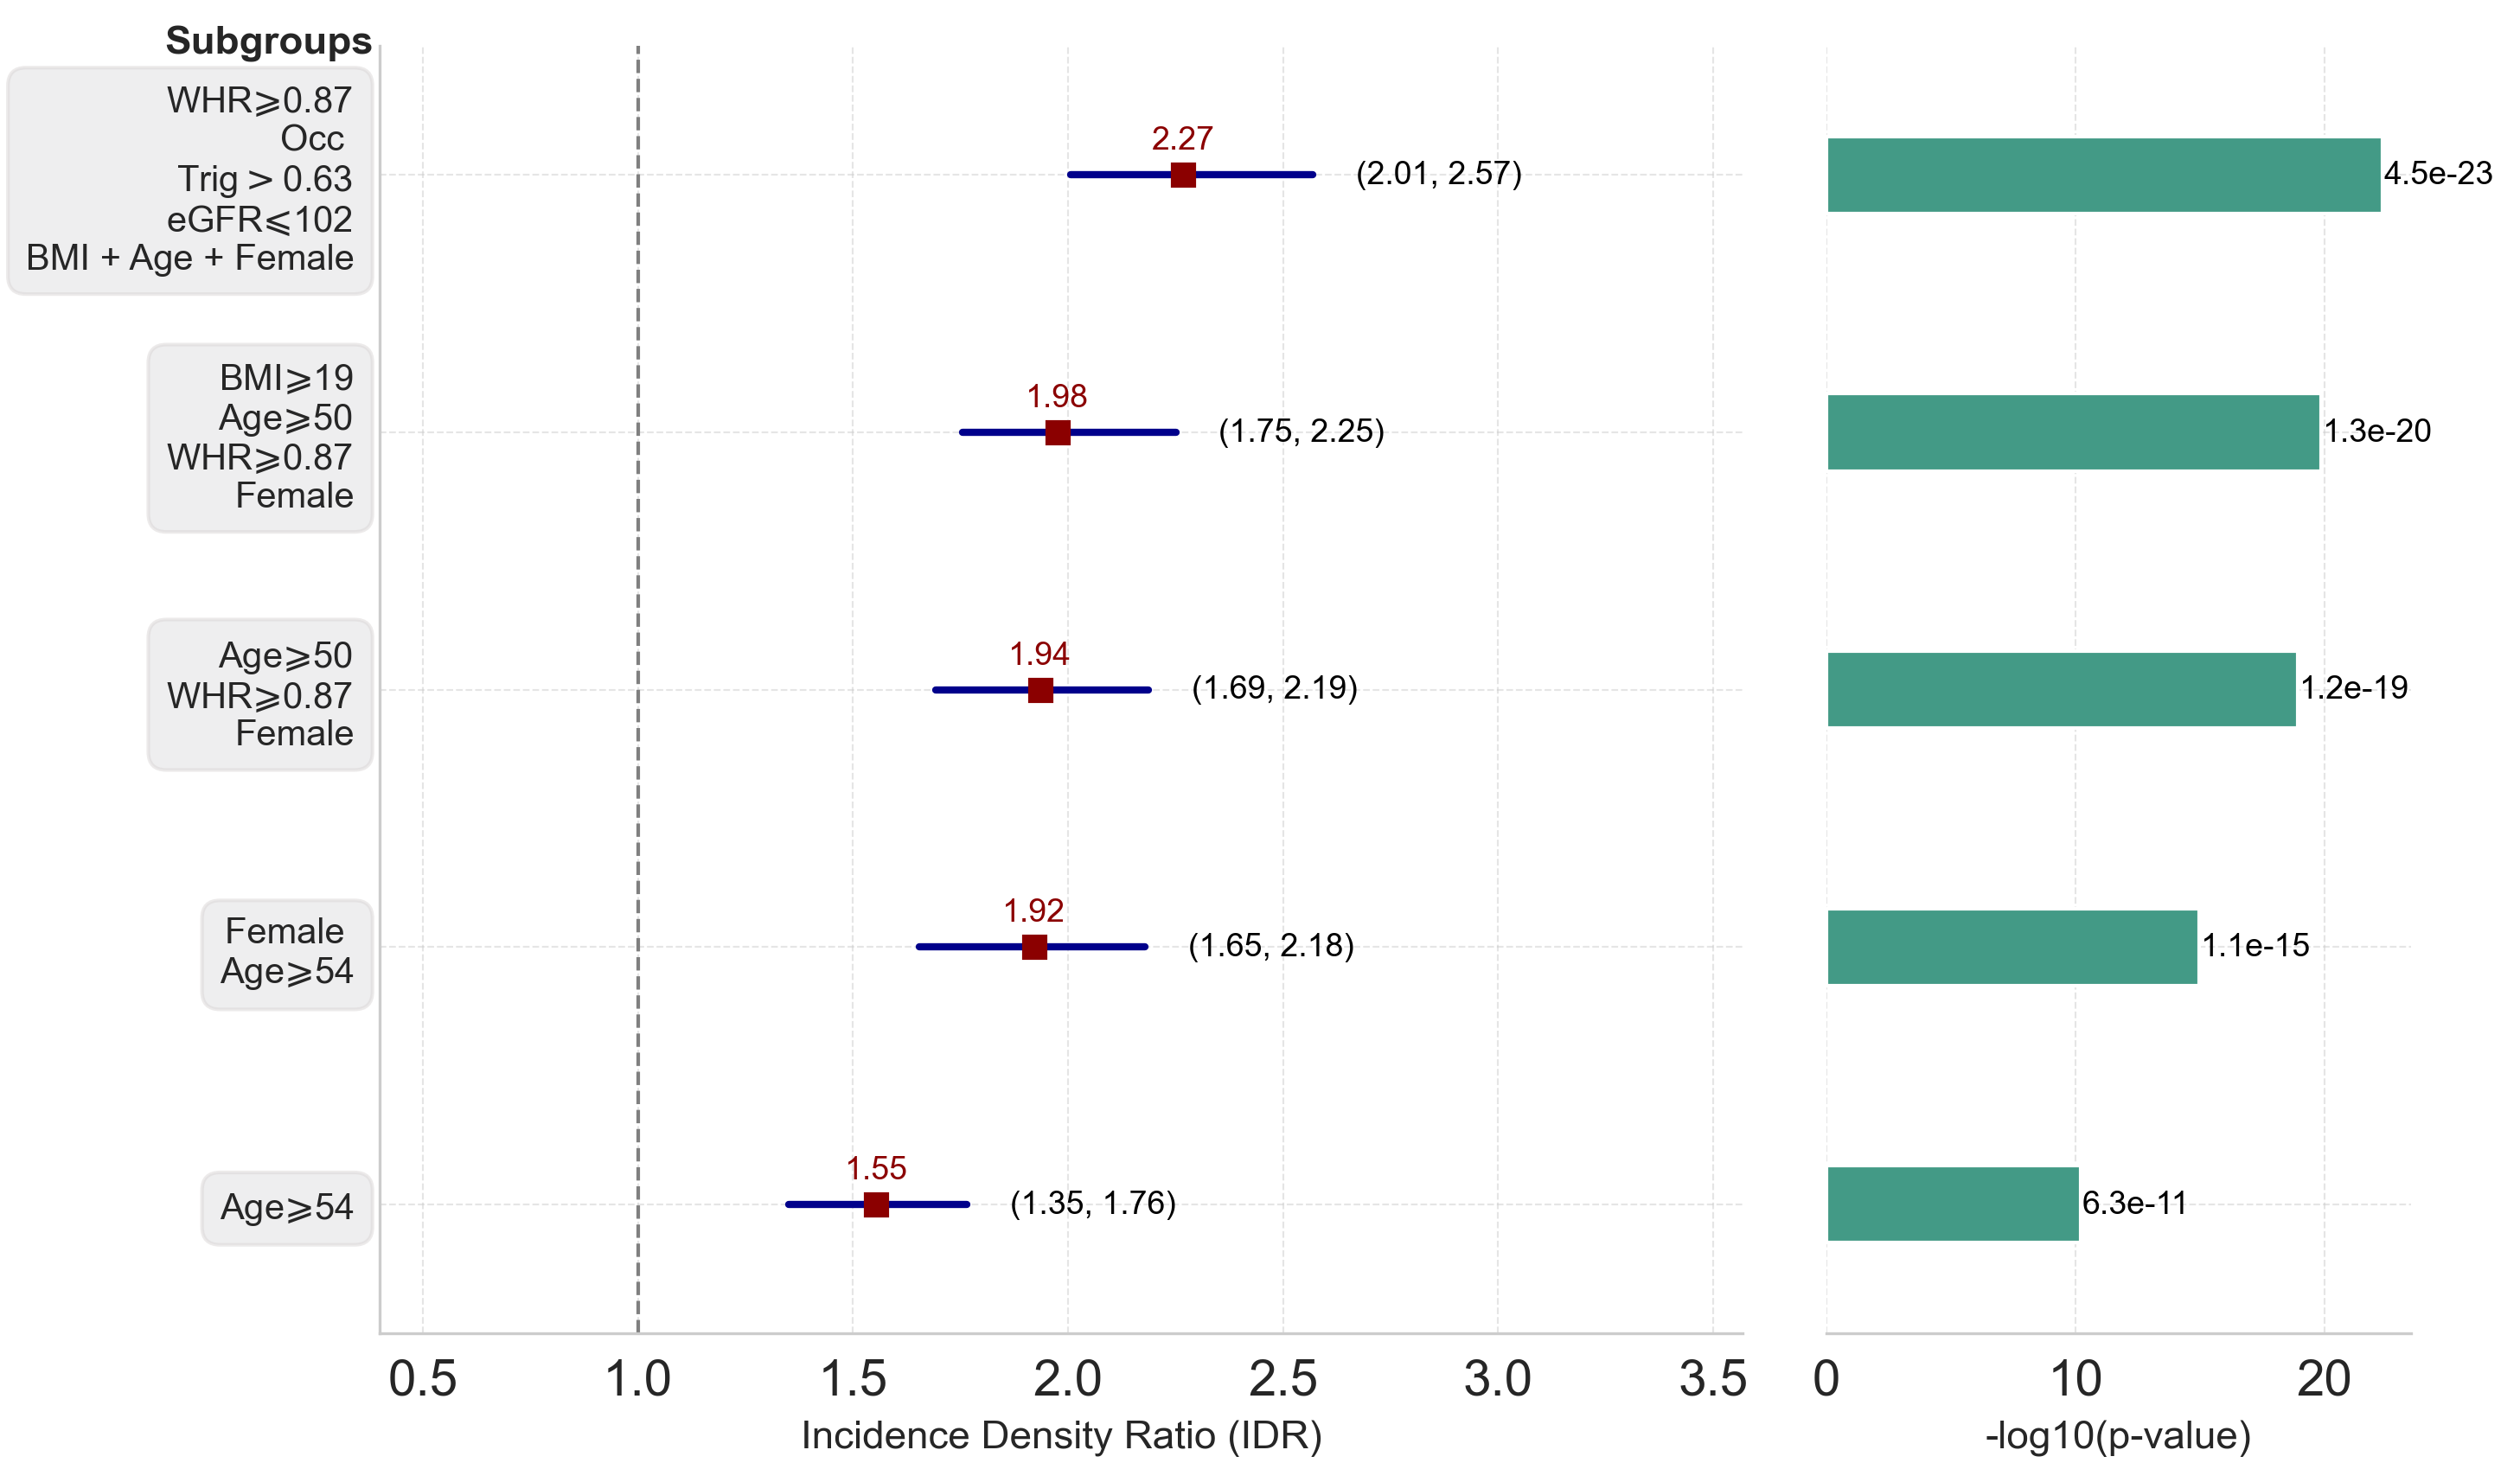

In [83]:
# Nairobi data (simplified for plot)
data_nairobi = pd.DataFrame({
    "label": [
        "WHR$\geqslant$0.87 \nOcc \nTrig$>$0.63 \neGFR$\leqslant$102 \nBMI + Age + Female",
        "BMI$\geqslant$19 \nAge$\geqslant$50 \nWHR$\geqslant$0.87 \nFemale",
        "Age$\geqslant$50 \nWHR$\geqslant$0.87 \nFemale",
        "Female \nAge$\geqslant$54",
        "Age$\geqslant$54"
    ],
    "IDR": [2.268, 1.975, 1.935, 1.921, 1.554],
    "p-value": [4.49e-23, 1.35e-20, 1.16e-19, 1.06e-15, 6.26e-11]
})

# Compute mock confidence intervals (±12% of IDR for variability)
data_nairobi["CI_lower"] = data_nairobi["IDR"] * np.random.uniform(0.86, 0.89, size=len(data_nairobi))
data_nairobi["CI_upper"] = data_nairobi["IDR"] * np.random.uniform(1.11, 1.14, size=len(data_nairobi))

# Reverse for plotting (top to bottom)
data_nairobi = data_nairobi.iloc[::-1].reset_index(drop=True)
y_positions = np.arange(len(data_nairobi))
n_groups = len(data_nairobi)

# Plot
fig, (ax_forest, ax_pvals) = plt.subplots(
    1, 2, 
    figsize=(10, 6),
    gridspec_kw={"width_ratios": [2.8, 1.2]}, dpi=300
)

# Forest plot
for i, row in data_nairobi.iterrows():
    ax_forest.plot([row["CI_lower"], row["CI_upper"]], [y_positions[i]] * 2, color="darkblue", lw=2)
    ax_forest.plot(row["IDR"], y_positions[i], "s", color="darkred", markersize=6)
    ax_forest.text(row["IDR"], y_positions[i] + 0.1, f"{row['IDR']:.2f}", ha="center", color="darkred", fontsize=9)
    ci_label = f"({row['CI_lower']:.2f}, {row['CI_upper']:.2f})"
    ax_forest.text(row["CI_upper"] + 0.1, y_positions[i], ci_label, va="center", fontsize=9, color="black")

ax_forest.axvline(x=1.0, color="gray", linestyle="--", lw=1)
ax_forest.set_yticks(y_positions)
ax_forest.set_yticklabels(data_nairobi["label"], fontsize=10)
for label in ax_forest.yaxis.get_ticklabels():
    label.set_bbox(dict(facecolor='#DEDEE0', edgecolor='#DAD6D6', alpha=0.5, pad=3, boxstyle='round,pad=0.5'))
ax_forest.set_xlabel("Incidence Density Ratio (IDR)", fontsize=11)
for spine in ["top", "right"]:
    ax_forest.spines[spine].set_visible(False)
x_min = min(data_nairobi["CI_lower"].min(), 0.5) - 0.1
x_max = data_nairobi["CI_upper"].max() + 1.0
ax_forest.set_xlim(x_min, x_max)
ax_forest.set_ylim(-0.5, n_groups - 0.5)
ax_forest.grid(True, linestyle="--", alpha=0.5,linewidth=0.5)


# P-value bar chart
pvals = data_nairobi["p-value"].clip(lower=1e-300)
neg_log_pvals = -np.log10(pvals)
bars = ax_pvals.barh(y_positions, neg_log_pvals, height=0.3, color="#439A86")
for spine in ["left", "right", "top"]:
    ax_pvals.spines[spine].set_visible(False)
ax_pvals.set_xlabel("-log10(p-value)", fontsize=11)
ax_pvals.set_ylim(ax_forest.get_ylim())
ax_pvals.set_yticks(y_positions)
ax_pvals.set_yticklabels([])
ax_pvals.grid(True, linestyle="--", alpha=0.5,linewidth=0.5)
for i, val in enumerate(neg_log_pvals):
    pval_text = f"{data_nairobi['p-value'][i]:.1e}"
    ax_pvals.text(val + 0.05, y_positions[i], pval_text, va="center", fontsize=9, color="black")

# Annotate "Subgroups" title
ax_forest.text(
    -0.1,
    n_groups - 0.56,
    'Subgroups',
    fontsize=11,
    fontweight='bold',
    ha='left',
    va='bottom'
)

plt.tight_layout()
plt.show()